# Notebook 02: Exploratory Data Analysis
##### Football Match Prediction 
##### Student Name: Vishal Chaudhary
##### Student Number: X23332794

### 1. Setup & Imports


In [292]:
#  Setup & Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

print("Libraries imported successfully!")
print(f"Analysis Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")


Libraries imported successfully!
Analysis Date: 2025-11-14 00:03:27


### 2. Data Loading

In [293]:

# Define paths
DATA_RAW_PATH = Path('/Users/vishalchaudhary/Desktop/Football_Project_FINAL/DOMAIN_APPLICATIONS_PROJECT/data/raw')
PROCESSED_PATH = Path('/Users/vishalchaudhary/Desktop/Football_Project_FINAL/DOMAIN_APPLICATIONS_PROJECT/data/processed')
RESULTS_PATH = Path('/Users/vishalchaudhary/Desktop/Football_Project_FINAL/DOMAIN_APPLICATIONS_PROJECT/results')
FIGURES_PATH = RESULTS_PATH / 'figures'
TABLES_PATH = RESULTS_PATH / 'tables'

# Create directories
PROCESSED_PATH.mkdir(parents=True, exist_ok=True)
RESULTS_PATH.mkdir(parents=True, exist_ok=True)
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

# Load datasets
df_fixtures = pd.read_csv(DATA_RAW_PATH / 'historical_fixtures_2018_2023_20251101_203250.csv')
df_2024_test = pd.read_csv(DATA_RAW_PATH / 'fixtures_2024_Finished_20251101_215726.csv')
df_league_teams = pd.read_csv(DATA_RAW_PATH / 'league_teams_20251101_215613.csv')
df_standings = pd.read_csv(DATA_RAW_PATH / 'league_standings_20251101_215708.csv')
df_h2h = pd.read_csv(DATA_RAW_PATH / 'h2h_matches_20251101_224848.csv')
df_squad = pd.read_csv(DATA_RAW_PATH / 'squad_basic_20251103_123202.csv')
df_players = pd.read_csv(DATA_RAW_PATH / 'top_500_player_stats_2018_2023.csv')
df_injuries = pd.read_csv(DATA_RAW_PATH / 'injuries_data_2018_2023_20251105_003341.csv')
fixture_stats = pd.read_csv(DATA_RAW_PATH/'fixture_statistics_complete.csv')
lineups = pd.read_csv(DATA_RAW_PATH/'lineups_complete.csv')



In [294]:
print(df_fixtures.columns.tolist())
print(df_2024_test.columns.tolist())
print(df_league_teams.columns.tolist())
print(df_standings.columns.tolist())
print(df_h2h.columns.tolist())
print(df_squad.columns.tolist())
print(df_players.columns.tolist())
print(df_injuries.columns.tolist())
print(fixture_stats.columns.tolist())
print(lineups.columns.tolist())


['fixture_id', 'date', 'timestamp', 'league_id', 'league_name', 'season', 'round', 'home_team_id', 'home_team_name', 'away_team_id', 'away_team_name', 'home_goals', 'away_goals', 'home_score_halftime', 'away_score_halftime', 'home_score_fulltime', 'away_score_fulltime', 'venue_name', 'venue_city', 'referee', 'status']
['fixture_id', 'date', 'timestamp', 'league_id', 'league_name', 'season', 'round', 'home_team_id', 'home_team_name', 'away_team_id', 'away_team_name', 'venue_name', 'venue_city', 'referee', 'status', 'status_long', 'home_goals', 'away_goals', 'home_score_halftime', 'away_score_halftime', 'home_score_fulltime', 'away_score_fulltime']
['team_id', 'team_name', 'league_id', 'league_name', 'season', 'matches_played_home', 'matches_played_away', 'matches_played_total', 'wins_home', 'wins_away', 'wins_total', 'draws_home', 'draws_away', 'draws_total', 'losses_home', 'losses_away', 'losses_total', 'goals_for_home', 'goals_for_away', 'goals_for_total', 'goals_for_avg_home', 'goals

### 3. Data Exploration

In [295]:
#Initial Inspection
print("DATASET OVERVIEW")
print(" HISTORICAL FIXTURES")
print("\nFirst 5 rows:")
display(df_fixtures.head())

print(f"\nDataset Info:")
print(f"  Total Matches: {len(df_fixtures):,}")
print(f"  Columns: {df_fixtures.shape[1]}")
print(f"  Date Range: {df_fixtures['date'].min()} to {df_fixtures['date'].max()}")

print("\n Leagues Distribution:")
print(df_fixtures['league_name'].value_counts())

print("\n Seasons Coverage:")
print(df_fixtures['season'].value_counts().sort_index())

DATASET OVERVIEW
 HISTORICAL FIXTURES

First 5 rows:


,fixture_id,date,timestamp,league_id,league_name,season,round,home_team_id,home_team_name,away_team_id,away_team_name,home_goals,away_goals,home_score_halftime,away_score_halftime,home_score_fulltime,away_score_fulltime,venue_name,venue_city,referee,status
0,65,2018-08-10T19:00:00+00:00,1533927600,39,Premier League,2018,Regular Season - 1,33,Manchester United,46,Leicester,2,1,1.000,0.000,2,1,Old Trafford,Manchester,"Andre Marriner, England",FT
1,66,2018-08-11T11:30:00+00:00,1533987000,39,Premier League,2018,Regular Season - 1,34,Newcastle,47,Tottenham,1,2,1.000,2.000,1,2,St James' Park,Newcastle upon Tyne,"Martin Atkinson, England",FT
2,67,2018-08-11T14:00:00+00:00,1533996000,39,Premier League,2018,Regular Season - 1,35,Bournemouth,43,Cardiff,2,0,1.000,0.000,2,0,Vitality Stadium,Bournemouth,"Kevin Friend, England",FT
3,68,2018-08-11T14:00:00+00:00,1533996000,39,Premier League,2018,Regular Season - 1,36,Fulham,52,Crystal Palace,0,2,0.000,1.000,0,2,Craven Cottage,London,"Mike Dean, England",FT
4,69,2018-08-11T14:00:00+00:00,1533996000,39,Premier League,2018,Regular Season - 1,37,Huddersfield,49,Chelsea,0,3,0.000,2.000,0,3,John Smith's Stadium,Huddersfield,"Chris Kavanagh, England",FT



Dataset Info:
  Total Matches: 18,894
  Columns: 21
  Date Range: 2018-06-26T15:00:00+00:00 to 2024-06-02T18:45:00+00:00

 Leagues Distribution:
league_name
Serie A                          2281
Premier League                   2280
La Liga                          2280
Ligue 1                          2111
UEFA Europa League               1917
Bundesliga                       1848
Primeira Liga                    1844
Eredivisie                       1828
UEFA Europa Conference League    1255
UEFA Champions League            1250
Name: count, dtype: int64

 Seasons Coverage:
season
2018    3181
2019    2986
2020    2993
2021    3278
2022    3265
2023    3191
Name: count, dtype: int64


In [296]:
#Initial Inspection
print("DATASET OVERVIEW")
print(" league standings")
print("\nFirst 5 rows:")
display(df_standings.head())

print(f"\nDataset Info:")
print(f"  Total Matches: {len(df_standings):,}")
print(f"  Columns: {df_standings.shape[1]}")

print("\n Leagues Distribution:")
print(df_standings['league_name'].value_counts())

print("\n Seasons Coverage:")
print(df_standings['season'].value_counts().sort_index())

DATASET OVERVIEW
 league standings

First 5 rows:


,season,league_id,league_name,team_id,team_name,rank,points,goal_diff,group,form,status,description,matches_played,wins,draws,losses,goals_for,goals_against,matches_played_home,wins_home,draws_home,losses_home,goals_for_home,goals_against_home,matches_played_away,wins_away,draws_away,losses_away,goals_for_away,goals_against_away,update_date,points_per_game,win_percentage,goals_per_game,goals_conceded_per_game
0,2018,39,Premier League,50,Manchester City,1,98,72,Premier League,WWWWW,NaN,Promotion - Champions League (Group Stage),38,32,2,4,95,23,19,18,0,1,57,12,19,14,2,3,38,11,2019-05-12T00:00:00+00:00,2.580,84.210,2.500,0.610
1,2018,39,Premier League,40,Liverpool,2,97,67,Premier League,WWWWW,NaN,Promotion - Champions League (Group Stage),38,30,7,1,89,22,19,17,2,0,55,10,19,13,5,1,34,12,2019-05-12T00:00:00+00:00,2.550,78.950,2.340,0.580
2,2018,39,Premier League,49,Chelsea,3,72,24,Premier League,DWDDL,NaN,Promotion - Champions League (Group Stage),38,21,9,8,63,39,19,12,6,1,39,12,19,9,3,7,24,27,2019-05-12T00:00:00+00:00,1.890,55.260,1.660,1.030
3,2018,39,Premier League,47,Tottenham,4,71,28,Premier League,DLLWL,NaN,Promotion - Champions League (Group Stage),38,23,2,13,67,39,19,12,2,5,34,16,19,11,0,8,33,23,2019-05-12T00:00:00+00:00,1.870,60.530,1.760,1.030
4,2018,39,Premier League,42,Arsenal,5,70,22,Premier League,WDLLL,NaN,Promotion - Europa League (Group Stage),38,21,7,10,73,51,19,14,3,2,42,16,19,7,4,8,31,35,2019-05-12T00:00:00+00:00,1.840,55.260,1.920,1.340



Dataset Info:
  Total Matches: 862
  Columns: 35

 Leagues Distribution:
league_name
Premier League                   120
La Liga                          120
Serie A                          120
Ligue 1                          118
Bundesliga                       108
Eredivisie                       108
Primeira Liga                    108
UEFA Champions League             24
UEFA Europa League                24
UEFA Europa Conference League     12
Name: count, dtype: int64

 Seasons Coverage:
season
2018    142
2019    142
2020    142
2021    146
2022    146
2023    144
Name: count, dtype: int64


In [297]:

#Initial Inspection
print("DATASET OVERVIEW")
print(" Player Statistics")
print("\nFirst 5 rows:")
display(df_players.head())

print(f"\nDataset Info:")
print(f"  Total Matches: {len(df_players):,}")
print(f"  Columns: {df_players.shape[1]}")

print("\n Seasons Coverage:")
print(df_players['season'].value_counts().sort_index())

DATASET OVERVIEW
 Player Statistics

First 5 rows:


,season,league,player_id,player_name,age,nationality,team,position,appearances,minutes,rating,goals_total,assists,shots_total,shots_on,passes_total,key_passes,tackles_total,interceptions,duels_total,duels_won,dribbles_success,fouls_committed
0,2019,UEFA Europa League,7558,M. Liendl,38.000,Austria,Wolfsberger AC,Midfielder,NaN,538.000,7.533,1.000,3.000,12.000,5.000,215.000,17.000,7.000,5.000,NaN,NaN,5.000,9.000
1,2019,UEFA Europa League,37150,J. van der Heijden,33.000,Netherlands,Feyenoord,Defender,NaN,270.000,7.500,0.000,NaN,0.000,0.000,35.000,0.000,1.000,1.000,NaN,NaN,0.000,3.000
2,2019,UEFA Europa League,47506,Raúl Carnero,34.000,Spain,Getafe,Defender,NaN,360.000,7.275,0.000,2.000,2.000,1.000,84.000,8.000,8.000,4.000,NaN,NaN,4.000,6.000
3,2019,UEFA Europa League,22082,J. Moulin,37.000,France,Saint Etienne,Goalkeeper,NaN,180.000,7.250,0.000,NaN,0.000,0.000,51.000,0.000,NaN,0.000,NaN,NaN,0.000,0.000
4,2019,UEFA Europa League,47265,Jorge Molina,41.000,Spain,Getafe,Attacker,NaN,209.000,7.020,1.000,NaN,7.000,1.000,45.000,4.000,1.000,0.000,NaN,NaN,4.000,2.000



Dataset Info:
  Total Matches: 21,000
  Columns: 23

 Seasons Coverage:
season
2019    1500
2020    4500
2021    5000
2022    5000
2023    5000
Name: count, dtype: int64


In [298]:
#Initial Inspection
print("DATASET OVERVIEW")
print(" Injury Data")
print("\nFirst 5 rows:")
display(df_injuries.head())

print(f"\nDataset Info:")
print(f"  Total Matches: {len(df_injuries):,}")
print(f"  Columns: {df_injuries.shape[1]}")

print("\n Seasons Coverage:")
print(df_injuries['season'].value_counts().sort_index())

DATASET OVERVIEW
 Injury Data

First 5 rows:


,season,league,player_id,player_name,age,team,fixture_id,fixture_date,injury_reason
0,2020,Premier League,19025,T. Cairney,NaN,Fulham,592799,2021-04-09T19:00:00+00:00,Knee Injury
1,2020,Premier League,19657,M. Rodak,NaN,Fulham,592799,2021-04-09T19:00:00+00:00,Finger Injury
2,2020,Premier League,18739,W. Boly,NaN,Wolves,592799,2021-04-09T19:00:00+00:00,Illness
3,2020,Premier League,2887,R. Jimenez,NaN,Wolves,592799,2021-04-09T19:00:00+00:00,Concussion
4,2020,Premier League,18740,Jonny,NaN,Wolves,592799,2021-04-09T19:00:00+00:00,Knee Injury



Dataset Info:
  Total Matches: 37,198
  Columns: 9

 Seasons Coverage:
season
2020     3790
2021    16492
2022    16916
Name: count, dtype: int64


In [299]:
#Initial Inspection
print("DATASET OVERVIEW")
print(" Fixture Statistics")
print("\nFirst 5 rows:")
display(fixture_stats.head())

print(f"\nDataset Info:")
print(f"  Total Matches: {len(fixture_stats):,}")
print(f"  Columns: {fixture_stats.shape[1]}")

print("\n Leagues Distribution:")
print(fixture_stats['league_name'].value_counts())

print("\n Seasons Coverage:")
print(fixture_stats['season'].value_counts().sort_index())

DATASET OVERVIEW
 Fixture Statistics

First 5 rows:


,fixture_id,league_id,league_name,season,date,home_team_id,home_team_name,away_team_id,away_team_name,home_shots_on_goal,away_shots_on_goal,home_total_shots,away_total_shots,home_fouls,away_fouls,home_corners,away_corners,home_possession,away_possession,home_yellow_cards,away_yellow_cards,home_passes_accurate,away_passes_accurate,home_passes_percent,away_passes_percent
0,65,39,Premier League,2018,2018-08-10 19:00:00+00:00,33,Manchester United,46,Leicester,6.000,4.000,8.000,13.000,11.000,8.000,2.000,5.000,46%,54%,2.000,1.000,399.000,450.000,82%,83%
1,66,39,Premier League,2018,2018-08-11 11:30:00+00:00,34,Newcastle,47,Tottenham,2.000,5.000,15.000,15.000,11.000,12.000,3.000,5.000,40%,60%,2.000,2.000,268.000,467.000,69%,82%
2,67,39,Premier League,2018,2018-08-11 14:00:00+00:00,35,Bournemouth,43,Cardiff,4.000,1.000,12.000,10.000,11.000,9.000,7.000,4.000,62%,38%,1.000,1.000,397.000,175.000,79%,61%
3,68,39,Premier League,2018,2018-08-11 14:00:00+00:00,36,Fulham,52,Crystal Palace,6.000,10.000,15.000,12.000,9.000,11.000,5.000,5.000,66%,34%,1.000,2.000,591.000,258.000,88%,74%
4,69,39,Premier League,2018,2018-08-11 14:00:00+00:00,37,Huddersfield,49,Chelsea,1.000,4.000,6.000,13.000,9.000,8.000,2.000,5.000,37%,63%,2.000,1.000,281.000,582.000,76%,88%



Dataset Info:
  Total Matches: 17,628
  Columns: 25

 Leagues Distribution:
league_name
Serie A                          2281
Premier League                   2280
La Liga                          2280
Ligue 1                          2111
Bundesliga                       1848
Eredivisie                       1828
Primeira Liga                    1765
UEFA Europa League               1234
UEFA Champions League            1069
UEFA Europa Conference League     932
Name: count, dtype: int64

 Seasons Coverage:
season
2018    2907
2019    2691
2020    2802
2021    2886
2022    3157
2023    3185
Name: count, dtype: int64


In [300]:
#Initial Inspection
print("DATASET OVERVIEW")
print(" Lineups Data")
print("\nFirst 5 rows:")
display(lineups.head())

print(f"\nDataset Info:")
print(f"  Total Rows: {len(lineups):,}")
print(f"  Columns: {lineups.shape[1]}")

print("\n Seasons Coverage:")
print(lineups['season'].value_counts().sort_index())

print("\nColumn Names:")
print(lineups.columns.tolist())


DATASET OVERVIEW
 Lineups Data

First 5 rows:


,fixture_id,league_id,league_name,season,date,home_team_id,home_team_name,away_team_id,away_team_name,home_formation,home_coach_id,home_coach_name,home_coach_photo,home_startXI_count,home_subs_count,home_startXI_players,away_formation,away_coach_id,away_coach_name,away_coach_photo,away_startXI_count,away_subs_count,away_startXI_players
0,65,39,Premier League,2018,2018-08-10 19:00:00+00:00,33,Manchester United,46,Leicester,4-3-3,2462.000,José Mourinho,https://media.api-sports.io/football/coachs/24...,11,7,David de Gea|M. Darmian|V. Lindelöf|L. Shaw|E....,4-2-3-1,43.000,C. Puel,https://media.api-sports.io/football/coachs/43...,11,7,K. Schmeichel|W. Morgan|H. Maguire|Ricardo Per...
1,66,39,Premier League,2018,2018-08-11 11:30:00+00:00,34,Newcastle,47,Tottenham,4-4-1-1,67.000,Rafael Benítez,https://media.api-sports.io/football/coachs/67...,11,7,M. Dúbravka|C. Clark|J. Lascelles|P. Dummett|D...,4-3-2-1,13.000,M. Pochettino,https://media.api-sports.io/football/coachs/13...,11,7,H. Lloris|J. Vertonghen|S. Aurier|B. Davies|D....
2,67,39,Premier League,2018,2018-08-11 14:00:00+00:00,35,Bournemouth,43,Cardiff,4-4-2,5.000,E. Howe,https://media.api-sports.io/football/coachs/5.png,11,7,A. Begović|C. Daniels|A. Smith|S. Cook|N. Aké|...,4-1-4-1,101.000,N. Warnock,https://media.api-sports.io/football/coachs/10...,11,7,N. Etheridge|L. Peltier|B. Écuélé Manga|S. Bam...
3,68,39,Premier League,2018,2018-08-11 14:00:00+00:00,36,Fulham,52,Crystal Palace,4-3-3,1892.000,S. Jokanović,https://media.api-sports.io/football/coachs/18...,11,7,Fabri|M. Le Marchand|C. Christie|J. Bryan|C. C...,4-4-2,9.000,R. Hodgson,https://media.api-sports.io/football/coachs/9.png,11,7,W. Hennessey|M. Sakho|J. Tomkins|P. van Aanhol...
4,69,39,Premier League,2018,2018-08-11 14:00:00+00:00,37,Huddersfield,49,Chelsea,3-5-1-1,1541.000,D. Wagner,https://media.api-sports.io/football/coachs/15...,11,7,B. Hamer|M. Jørgensen|C. Löwe|C. Schindler|T. ...,4-3-3,2412.000,M. Sarri,https://media.api-sports.io/football/coachs/24...,11,7,Kepa|David Luiz|Azpilicueta|Marcos Alonso|A. R...



Dataset Info:
  Total Rows: 18,011
  Columns: 23

 Seasons Coverage:
season
2018    3058
2019    2815
2020    2842
2021    3108
2022    3116
2023    3072
Name: count, dtype: int64

Column Names:
['fixture_id', 'league_id', 'league_name', 'season', 'date', 'home_team_id', 'home_team_name', 'away_team_id', 'away_team_name', 'home_formation', 'home_coach_id', 'home_coach_name', 'home_coach_photo', 'home_startXI_count', 'home_subs_count', 'home_startXI_players', 'away_formation', 'away_coach_id', 'away_coach_name', 'away_coach_photo', 'away_startXI_count', 'away_subs_count', 'away_startXI_players']


In [301]:
# Convert dates
print("\n Converting date columns...")
df_fixtures['date'] = pd.to_datetime(df_fixtures['date'])
df_2024_test['date'] = pd.to_datetime(df_2024_test['date'])
if 'date' in df_injuries.columns:
    df_injuries['date'] = pd.to_datetime(df_injuries['date'], errors='coerce')
print(" Dates converted!")


 Converting date columns...
 Dates converted!


### 4. TOP 500 PLAYERS ANALYSIS

In [302]:

# TOP 500 PLAYERS ANALYSIS 

print("TOP 500 PLAYERS STATISTICS ANALYSIS")

print(" Player Stats Overview:")
print(f"  Total Player Records: {len(df_players):,}")
print(f"  Unique Players: {df_players['player_id'].nunique():,}")
print(f"  Unique Teams: {df_players['team'].nunique():,}")
print(f"  Leagues Covered: {df_players['league'].nunique()}")
print(f"  Seasons: {sorted(df_players['season'].unique())}")



TOP 500 PLAYERS STATISTICS ANALYSIS
 Player Stats Overview:
  Total Player Records: 21,000
  Unique Players: 11,627
  Unique Teams: 537
  Leagues Covered: 10
  Seasons: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]


In [303]:
print("\n Players by League:")
print(df_players['league'].value_counts())


 Players by League:
league
UEFA Europa League               2500
Eredivisie                       2500
Primeira Liga                    2500
Premier League                   2000
La Liga                          2000
Serie A                          2000
Bundesliga                       2000
Ligue 1                          2000
UEFA Champions League            2000
UEFA Europa Conference League    1500
Name: count, dtype: int64


In [304]:
print("\n Players by Season:")
print(df_players['season'].value_counts().sort_index())


 Players by Season:
season
2019    1500
2020    4500
2021    5000
2022    5000
2023    5000
Name: count, dtype: int64


In [305]:
print("\n Position Distribution:")
print(df_players['position'].value_counts())


 Position Distribution:
position
Defender      6717
Midfielder    6702
Attacker      4593
Goalkeeper    2988
Name: count, dtype: int64


In [306]:
# Clean player data - remove players with rating = 0
print(f"\n Cleaning player data...")
print(f"  Before: {len(df_players):,} records")
df_players_clean = df_players[df_players['rating'] > 0].copy()
print(f"  After (rating > 0): {len(df_players_clean):,} records")
print(f"  Removed: {len(df_players) - len(df_players_clean):,} records with no rating")


 Cleaning player data...
  Before: 21,000 records
  After (rating > 0): 10,266 records
  Removed: 10,734 records with no rating


In [307]:
# Player statistics summary
print("\n Player Performance Statistics:")
player_stats_summary = df_players_clean[['rating', 'goals_total', 'assists', 
                                          'appearances', 'minutes']].describe()
display(player_stats_summary)


 Player Performance Statistics:


,rating,goals_total,assists,appearances,minutes
count,10266.000,9706.000,4599.000,0.000,10219.000
mean,6.741,1.421,2.184,NaN,1105.320
std,0.294,2.829,2.078,NaN,968.654
min,3.000,0.000,0.000,NaN,0.000
25%,6.581,0.000,1.000,NaN,200.000
50%,6.733,0.000,2.000,NaN,860.000
75%,6.900,2.000,3.000,NaN,1882.000
max,9.000,41.000,18.000,NaN,3427.000


In [308]:
# Top performers
print("\n Top 10 Players by Rating (Overall):")
top_players = df_players_clean.nlargest(10, 'rating')[
    ['player_name', 'team', 'league', 'season', 'rating', 'goals_total', 'assists', 'appearances']
]
display(top_players)


 Top 10 Players by Rating (Overall):


,player_name,team,league,season,rating,goals_total,assists,appearances
1000,Gonçalo Ramos,Benfica,Primeira Liga,2019,9.000,2.000,NaN,NaN
19500,N. Ćetković,Borac Banja Luka,UEFA Europa Conference League,2023,8.500,0.000,NaN,NaN
7000,M. Zaccagni,Lazio,Serie A,2021,8.400,4.000,NaN,NaN
2000,L. Messi,Barcelona,La Liga,2020,8.329,30.000,9.000,NaN
9000,S. Evangelou,Sheriff Tiraspol,UEFA Europa League,2021,8.300,0.000,NaN,NaN
10000,C. van den Berg,Willem II,Eredivisie,2021,8.300,0.000,NaN,NaN
10001,I. El Maach,Waalwijk,Eredivisie,2021,8.300,0.000,NaN,NaN
12000,S. Sirigu,Fiorentina,Serie A,2022,8.300,0.000,NaN,NaN
17000,S. Perilli,Verona,Serie A,2023,8.300,0.000,0.000,NaN
20000,M. Spenkelink,Waalwijk,Eredivisie,2023,8.300,0.000,NaN,NaN


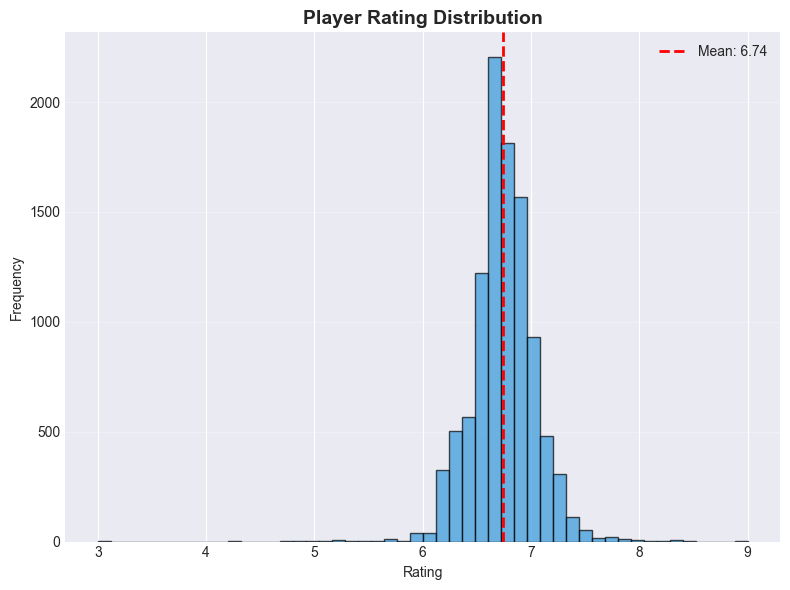

In [309]:
# Rating Distribution
plt.figure(figsize=(8, 6))
plt.hist(df_players_clean['rating'], bins=50, color='#3498db', alpha=0.7, edgecolor='black')
plt.axvline(df_players_clean['rating'].mean(), color='red', linestyle='--', linewidth=2,
            label=f"Mean: {df_players_clean['rating'].mean():.2f}")
plt.title('Player Rating Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'player_rating_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


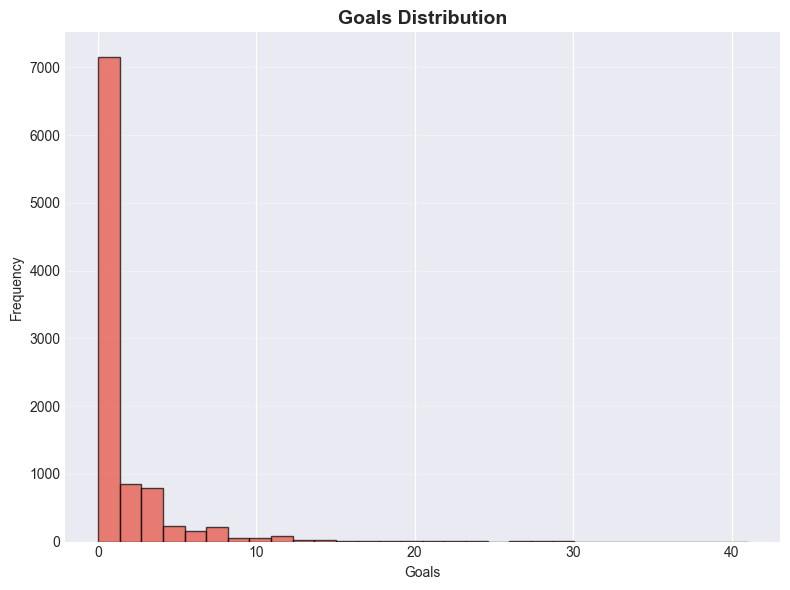

In [310]:
# Goals Distribution
plt.figure(figsize=(8, 6))
plt.hist(df_players_clean['goals_total'].dropna(), bins=30, color='#e74c3c', alpha=0.7, edgecolor='black')
plt.title('Goals Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Goals')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'player_goals_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


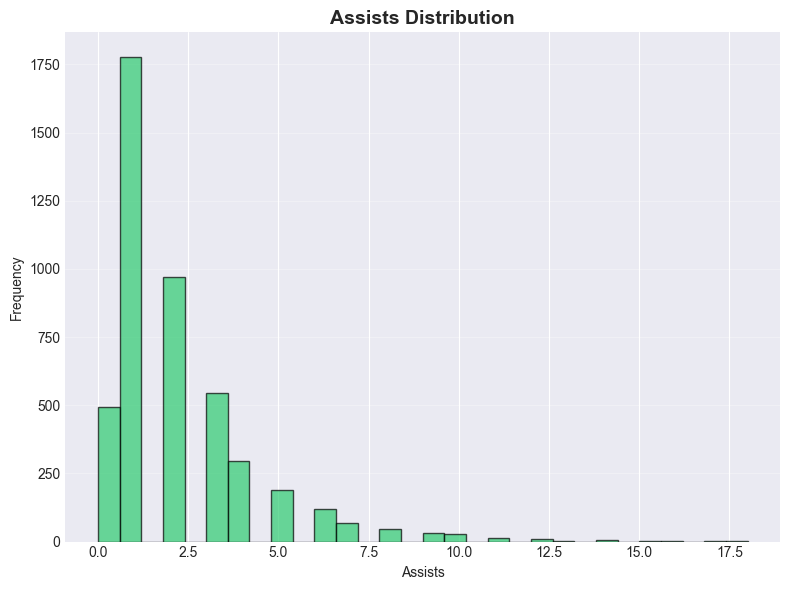

In [311]:
# Assists Distribution
plt.figure(figsize=(8, 6))
plt.hist(df_players_clean['assists'].dropna(), bins=30, color='#2ecc71', alpha=0.7, edgecolor='black')
plt.title('Assists Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Assists')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'player_assists_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


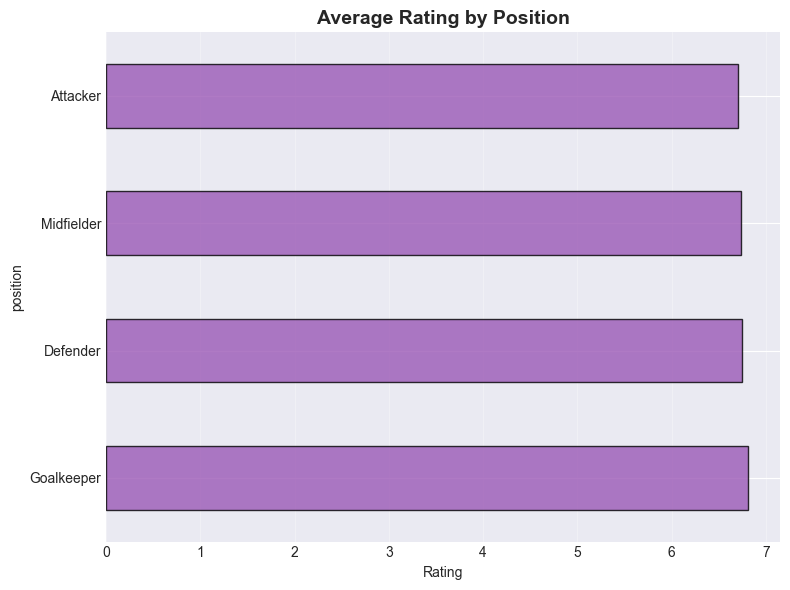

In [312]:
# Average Rating by Position
rating_by_position = df_players_clean.groupby('position')['rating'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 6))
rating_by_position.plot(kind='barh', color='#9b59b6', alpha=0.8, edgecolor='black')
plt.title('Average Rating by Position', fontsize=14, fontweight='bold')
plt.xlabel('Rating')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'rating_by_position.png', dpi=300, bbox_inches='tight')
plt.show()


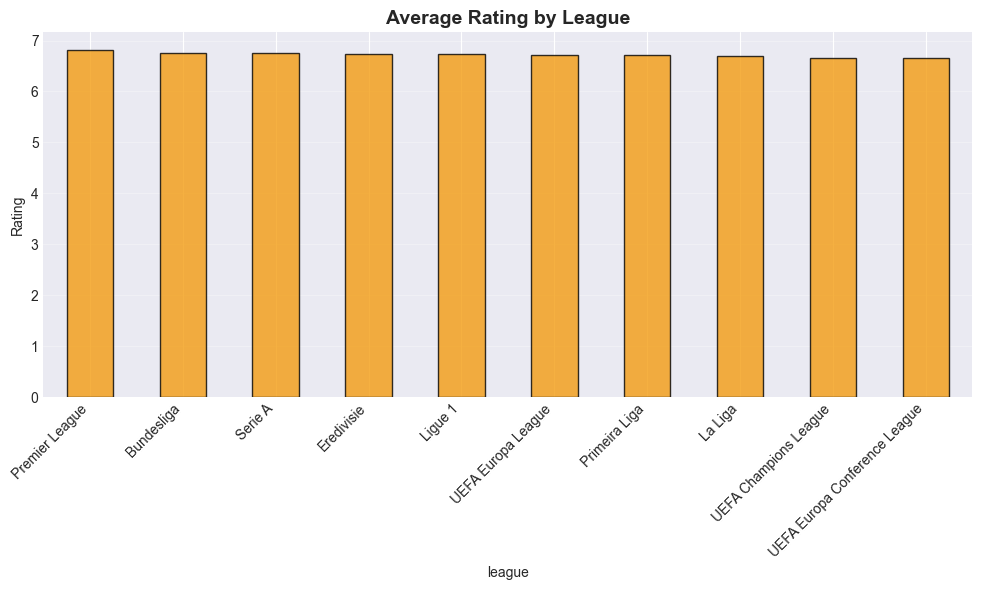

In [313]:
# Average Rating by League
rating_by_league = df_players_clean.groupby('league')['rating'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
rating_by_league.plot(kind='bar', color='#f39c12', alpha=0.8, edgecolor='black')
plt.title('Average Rating by League', fontsize=14, fontweight='bold')
plt.ylabel('Rating')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'rating_by_league.png', dpi=300, bbox_inches='tight')
plt.show()


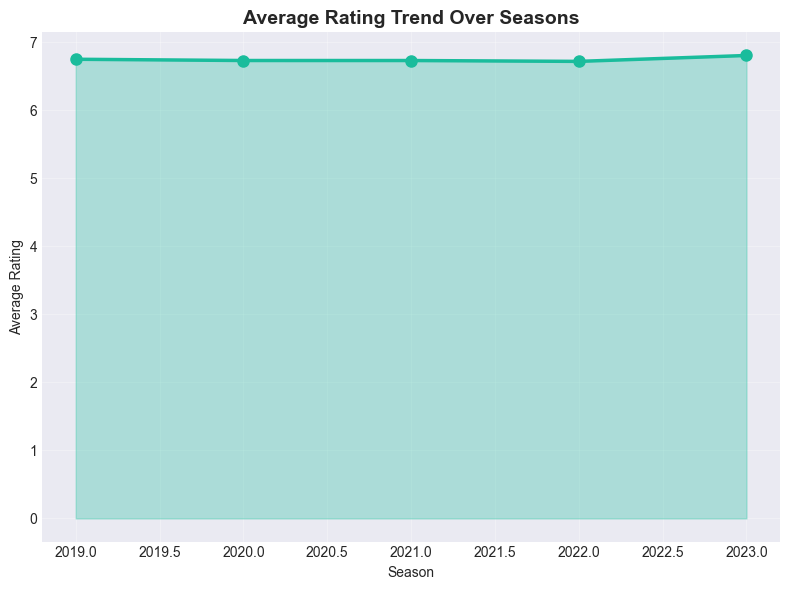

In [314]:
# Rating Trend Over Seasons
rating_by_season = df_players_clean.groupby('season')['rating'].mean()

plt.figure(figsize=(8, 6))
plt.plot(rating_by_season.index, rating_by_season.values, marker='o', linewidth=2.5, markersize=8, color='#1abc9c')
plt.fill_between(rating_by_season.index, rating_by_season.values, alpha=0.3, color='#1abc9c')
plt.title('Average Rating Trend Over Seasons', fontsize=14, fontweight='bold')
plt.xlabel('Season')
plt.ylabel('Average Rating')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'rating_trend_over_seasons.png', dpi=300, bbox_inches='tight')
plt.show()


In [315]:
# Team strength calculation (aggregate player ratings)
print("\n Team Strength Analysis (Based on Player Ratings):")
team_strength = df_players_clean.groupby(['season', 'league', 'team']).agg({
    'rating': ['mean', 'count'],
    
    
}).round(2)
team_strength.columns = ['Avg_Rating', 'Num_Players']
team_strength = team_strength.reset_index()
team_strength = team_strength.sort_values('Avg_Rating', ascending=False)

print("\nTop 10 Strongest Teams (by avg player rating):")
display(team_strength.head(10))
# If you have a FEATURES_PATH defined as a pathlib.Path
team_strength.to_csv(TABLES_PATH / 'team_strength_by_ratings.csv', index=False)
print(f"Saved cleaned dataset to '{TABLES_PATH}/df_merged_cleaned.csv'")




 Team Strength Analysis (Based on Player Ratings):

Top 10 Strongest Teams (by avg player rating):


,season,league,team,Avg_Rating,Num_Players
812,2023,UEFA Europa Conference League,Borac Banja Luka,8.500,1
837,2023,UEFA Europa League,Ajax,7.800,1
433,2021,UEFA Europa League,Spartak Moscow,7.630,2
47,2019,UEFA Europa League,Wolfsberger AC,7.530,1
43,2019,UEFA Europa League,Feyenoord,7.500,1
809,2023,UEFA Europa Conference League,Alashkert,7.420,2
606,2022,UEFA Europa Conference League,Neftchi Baku,7.300,1
422,2021,UEFA Europa League,Marseille,7.300,1
226,2020,UEFA Europa League,Real Sociedad,7.300,1
222,2020,UEFA Europa League,Nice,7.300,1


Saved cleaned dataset to '/Users/vishalchaudhary/Desktop/Football_Project_FINAL/DOMAIN_APPLICATIONS_PROJECT/results/tables/df_merged_cleaned.csv'


### 5. INJURIES DATA ANALYSIS

In [316]:
# INJURIES DATA ANALYSIS
print("INJURIES DATA ANALYSIS")

print(" Injuries Overview:")
print(f"  Total Injury Records: {len(df_injuries):,}")
print(f"  Unique Players Injured: {df_injuries['player_id'].nunique():,}")
print(f"  Unique Teams: {df_injuries['team'].nunique():,}")
print(f"  Leagues Covered: {df_injuries['league'].nunique()}")
print(f"  Seasons: {sorted(df_injuries['season'].unique())}")

INJURIES DATA ANALYSIS
 Injuries Overview:
  Total Injury Records: 37,198
  Unique Players Injured: 4,300
  Unique Teams: 210
  Leagues Covered: 9
  Seasons: [np.int64(2020), np.int64(2021), np.int64(2022)]


In [317]:
print("\n Injuries by League:")
print(df_injuries['league'].value_counts())


 Injuries by League:
league
Premier League           6217
Ligue 1                  5969
Serie A                  5849
La Liga                  5793
Bundesliga               5281
Eredivisie               3894
UEFA Champions League    1999
UEFA Europa League       1969
Primeira Liga             227
Name: count, dtype: int64


In [318]:
print("\n Injuries by Season:")
print(df_injuries['season'].value_counts().sort_index())



 Injuries by Season:
season
2020     3790
2021    16492
2022    16916
Name: count, dtype: int64


In [319]:
print("\n Injury Types (Top 10):")
if 'type' in df_injuries.columns or 'reason' in df_injuries.columns:
    injury_col = 'type' if 'type' in df_injuries.columns else 'reason'
    print(df_injuries[injury_col].value_counts().head(10))




 Injury Types (Top 10):


In [320]:
# Teams with most injuries
print("\n Teams with Most Injuries (Top 15):")
injuries_by_team = df_injuries.groupby(['season', 'league', 'team']).size().reset_index(name='injury_count')
injuries_by_team_total = df_injuries.groupby('team').size().sort_values(ascending=False)
print(injuries_by_team_total.head(15))




 Teams with Most Injuries (Top 15):
team
Borussia Dortmund      593
Juventus               583
PSV Eindhoven          581
Paris Saint Germain    545
Real Sociedad          540
Manchester United      537
Barcelona              485
Liverpool              483
AC Milan               447
Chelsea                429
Bayer Leverkusen       424
Real Madrid            421
Sevilla                419
Bayern Munich          411
1899 Hoffenheim        407
dtype: int64


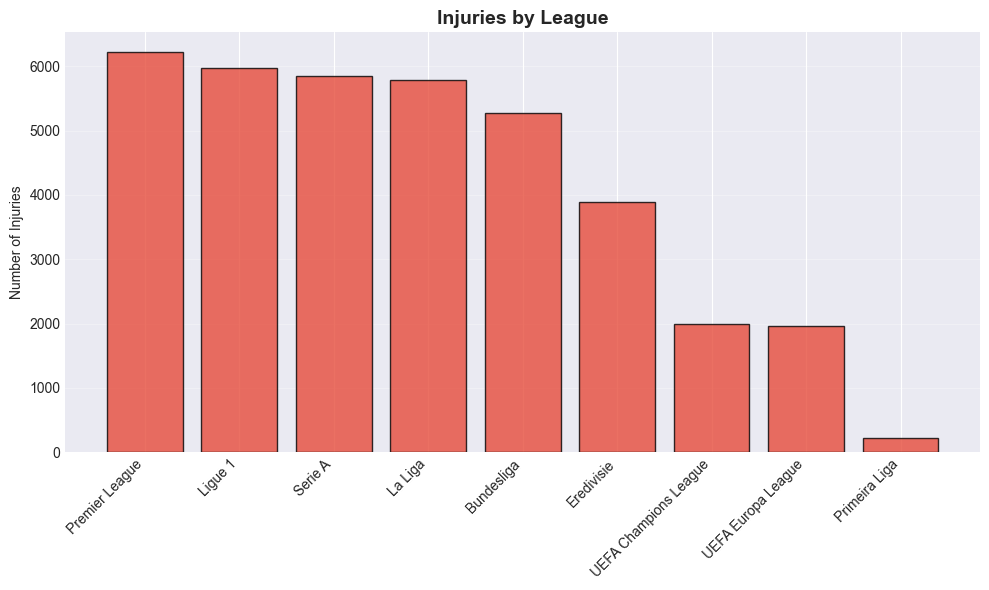

In [321]:
# Injuries by League
plt.figure(figsize=(10, 6))
injuries_by_league = df_injuries['league'].value_counts()

plt.bar(range(len(injuries_by_league)), injuries_by_league.values, color='#e74c3c', alpha=0.8, edgecolor='black')
plt.xticks(range(len(injuries_by_league)), injuries_by_league.index, rotation=45, ha='right')
plt.title('Injuries by League', fontsize=14, fontweight='bold')
plt.ylabel('Number of Injuries')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'injuries_by_league.png', dpi=300, bbox_inches='tight')
plt.show()


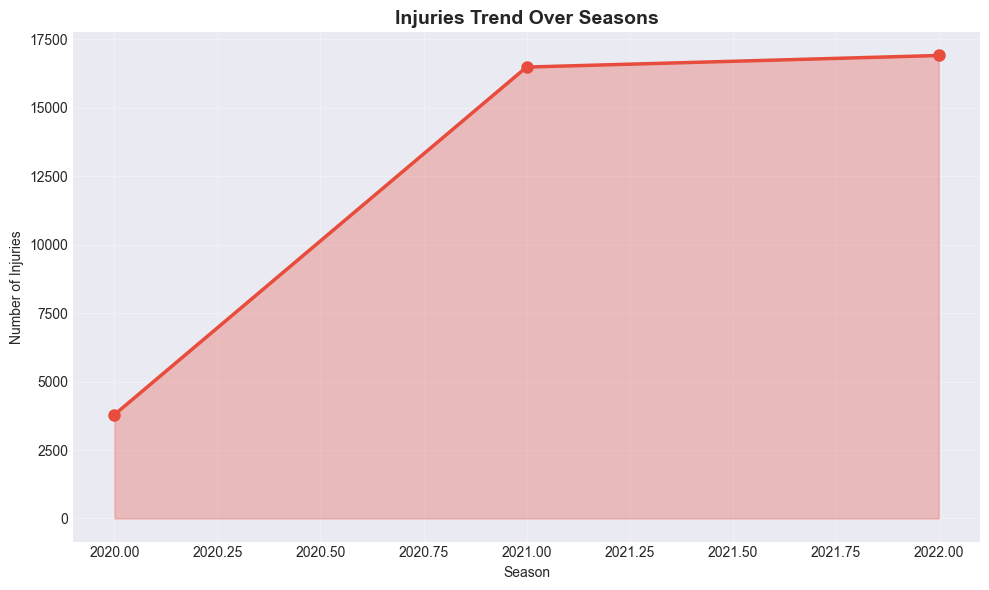

In [322]:
# Injuries Trend Over Seasons
plt.figure(figsize=(10, 6))
injuries_by_season = df_injuries['season'].value_counts().sort_index()

plt.plot(injuries_by_season.index, injuries_by_season.values, marker='o', linewidth=2.5, markersize=8, color='#e74c3c')
plt.fill_between(injuries_by_season.index, injuries_by_season.values, alpha=0.3, color='#e74c3c')
plt.title('Injuries Trend Over Seasons', fontsize=14, fontweight='bold')
plt.xlabel('Season')
plt.ylabel('Number of Injuries')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'injuries_trend_over_seasons.png', dpi=300, bbox_inches='tight')
plt.show()


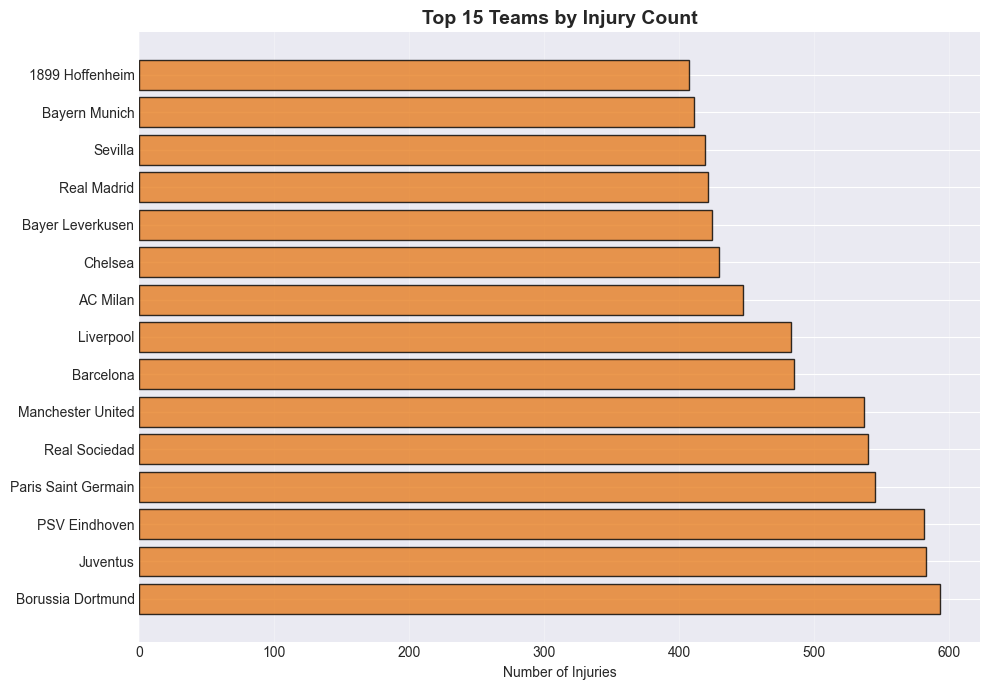

In [323]:
# Top 15 Teams by Injury Count
plt.figure(figsize=(10, 7))
top_injured_teams = df_injuries['team'].value_counts().head(15)

plt.barh(range(len(top_injured_teams)), top_injured_teams.values, color='#e67e22', alpha=0.8, edgecolor='black')
plt.yticks(range(len(top_injured_teams)), top_injured_teams.index)
plt.title('Top 15 Teams by Injury Count', fontsize=14, fontweight='bold')
plt.xlabel('Number of Injuries')
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'top_teams_injury_count.png', dpi=300, bbox_inches='tight')
plt.show()


In [324]:
# Calculate injury impact per team
print("\n Injury Impact by Team-Season:")
injury_impact = df_injuries.groupby(['season', 'league', 'team']).agg({
    'player_id': 'count'  # Total injuries
}).reset_index()
injury_impact.columns = ['season', 'league', 'team', 'total_injuries']
injury_impact = injury_impact.sort_values('total_injuries', ascending=False)

print("\nTop 10 Team-Seasons with Most Injuries:")
display(injury_impact.head(10))



 Injury Impact by Team-Season:

Top 10 Team-Seasons with Most Injuries:


,season,league,team,total_injuries
462,2022,Serie A,Juventus,260
186,2021,Eredivisie,PSV Eindhoven,252
156,2021,Bundesliga,Borussia Dortmund,247
415,2022,Ligue 1,Angers,244
228,2021,Ligue 1,Paris Saint Germain,243
197,2021,La Liga,Barcelona,243
449,2022,Premier League,Nottingham Forest,235
447,2022,Premier League,Manchester United,232
398,2022,La Liga,Cadiz,226
358,2022,Bundesliga,FC Augsburg,221


### 6. Fixtures Statistics

In [325]:
print(f"Fixture Statistics Dataset Shape: {fixture_stats.shape}")
print(f"\nNumber of matches with statistics: {fixture_stats['fixture_id'].nunique()}")

Fixture Statistics Dataset Shape: (17628, 25)

Number of matches with statistics: 17628


In [326]:
# Basic information about the dataset
fixture_stats.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17628 entries, 0 to 17627
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixture_id            17628 non-null  int64  
 1   league_id             17628 non-null  int64  
 2   league_name           17628 non-null  object 
 3   season                17628 non-null  int64  
 4   date                  17628 non-null  object 
 5   home_team_id          17628 non-null  int64  
 6   home_team_name        17628 non-null  object 
 7   away_team_id          17628 non-null  int64  
 8   away_team_name        17628 non-null  object 
 9   home_shots_on_goal    17266 non-null  float64
 10  away_shots_on_goal    17266 non-null  float64
 11  home_total_shots      17278 non-null  float64
 12  away_total_shots      17278 non-null  float64
 13  home_fouls            17278 non-null  float64
 14  away_fouls            17278 non-null  float64
 15  home_corners       

In [327]:

# Statistical summary of numeric columns
fixture_stats.describe()

,fixture_id,league_id,season,home_team_id,away_team_id,home_shots_on_goal,away_shots_on_goal,home_total_shots,away_total_shots,home_fouls,away_fouls,home_corners,away_corners,home_yellow_cards,away_yellow_cards,home_passes_accurate,away_passes_accurate
count,17628.000,17628.000,17628.000,17628.000,17628.000,17266.000,17266.000,17278.000,17278.000,17278.000,17278.000,17599.000,17599.000,16985.000,16985.000,16846.000,16846.000
mean,604057.890,119.805,2020.581,413.898,416.106,4.842,3.951,13.815,11.313,12.338,12.478,5.423,4.415,2.056,2.296,371.500,348.269
std,368392.815,177.567,1.726,883.985,898.932,2.642,2.373,5.546,4.929,4.099,4.179,3.010,2.659,1.389,1.431,127.139,119.991
min,65.000,2.000,2018.000,33.000,33.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,32.000,58.000
25%,212415.750,39.000,2019.000,106.000,106.000,3.000,2.000,10.000,8.000,9.000,10.000,3.000,2.000,1.000,1.000,277.000,261.000
50%,710657.500,88.000,2021.000,217.000,217.000,5.000,4.000,13.000,11.000,12.000,12.000,5.000,4.000,2.000,2.000,358.000,335.000
75%,881831.250,135.000,2022.000,529.000,529.000,6.000,5.000,17.000,14.000,15.000,15.000,7.000,6.000,3.000,3.000,451.000,422.000
max,1201625.000,848.000,2023.000,21595.000,21595.000,20.000,23.000,47.000,45.000,33.000,35.000,23.000,19.000,10.000,9.000,981.000,904.000


In [328]:
# Check for missing values
missing_stats = fixture_stats.isnull().sum()
missing_stats[missing_stats > 0]

home_shots_on_goal      362
away_shots_on_goal      362
home_total_shots        350
away_total_shots        350
home_fouls              350
away_fouls              350
home_corners             29
away_corners             29
home_possession         518
away_possession         518
home_yellow_cards       643
away_yellow_cards       643
home_passes_accurate    782
away_passes_accurate    782
home_passes_percent     782
away_passes_percent     782
dtype: int64

In [329]:
# Check missing values percentage
missing_percentage = (fixture_stats.isnull().sum() / len(fixture_stats)) * 100
missing_percentage[missing_percentage > 0].sort_values(ascending=False)

home_passes_accurate   4.436
away_passes_accurate   4.436
home_passes_percent    4.436
away_passes_percent    4.436
home_yellow_cards      3.648
away_yellow_cards      3.648
home_possession        2.939
away_possession        2.939
home_shots_on_goal     2.054
away_shots_on_goal     2.054
home_total_shots       1.985
away_total_shots       1.985
home_fouls             1.985
away_fouls             1.985
home_corners           0.165
away_corners           0.165
dtype: float64

In [330]:
# Distribution of matches by season
fixture_stats['season'].value_counts().sort_index()
# Distribution of matches by league
fixture_stats['league_name'].value_counts()

league_name
Serie A                          2281
Premier League                   2280
La Liga                          2280
Ligue 1                          2111
Bundesliga                       1848
Eredivisie                       1828
Primeira Liga                    1765
UEFA Europa League               1234
UEFA Champions League            1069
UEFA Europa Conference League     932
Name: count, dtype: int64

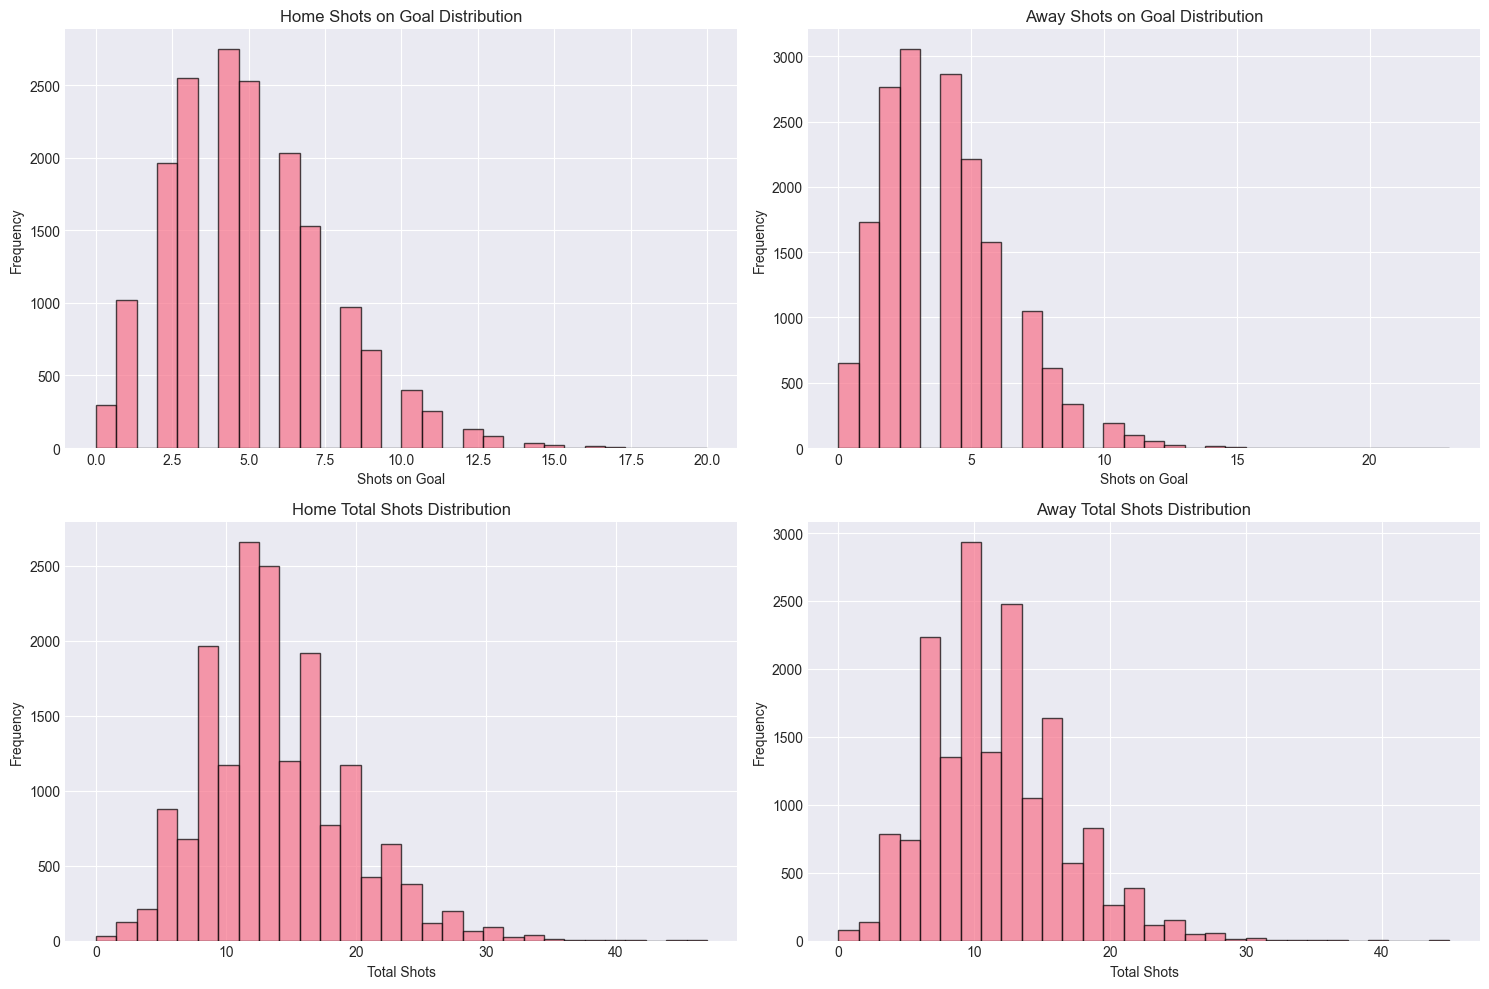

In [331]:
# Analyze shooting statistics
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].hist(fixture_stats['home_shots_on_goal'].dropna(), bins=30, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Home Shots on Goal Distribution')
axes[0, 0].set_xlabel('Shots on Goal')
axes[0, 0].set_ylabel('Frequency')

axes[0, 1].hist(fixture_stats['away_shots_on_goal'].dropna(), bins=30, edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Away Shots on Goal Distribution')
axes[0, 1].set_xlabel('Shots on Goal')
axes[0, 1].set_ylabel('Frequency')

axes[1, 0].hist(fixture_stats['home_total_shots'].dropna(), bins=30, edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Home Total Shots Distribution')
axes[1, 0].set_xlabel('Total Shots')
axes[1, 0].set_ylabel('Frequency')

axes[1, 1].hist(fixture_stats['away_total_shots'].dropna(), bins=30, edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Away Total Shots Distribution')
axes[1, 1].set_xlabel('Total Shots')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'goal_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

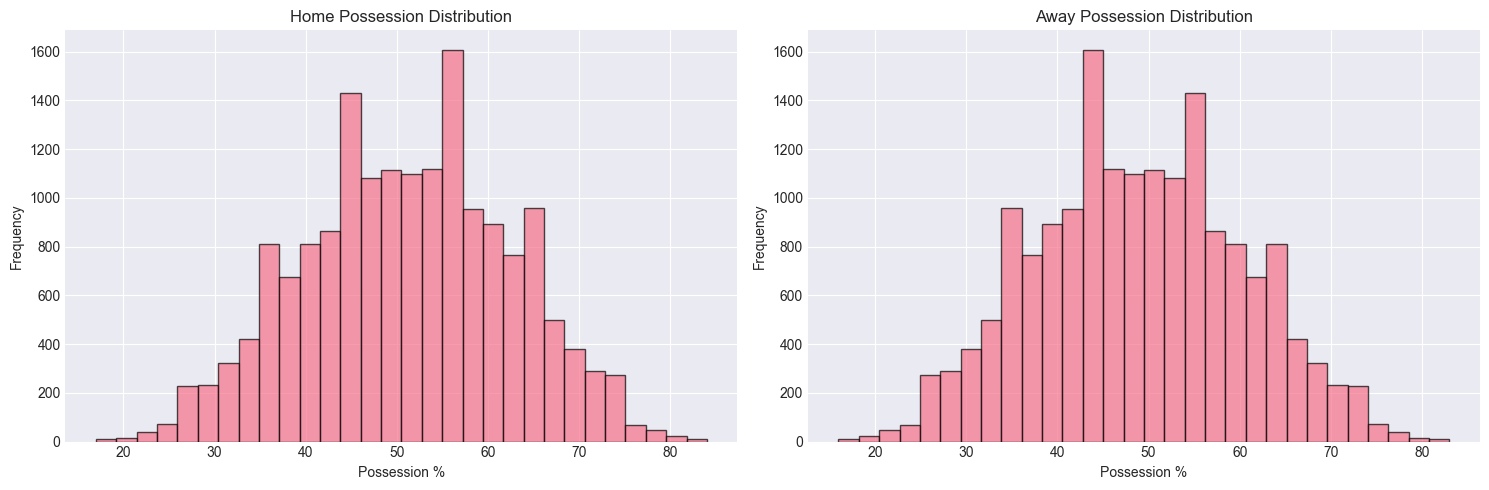

In [332]:
# Analyze possession statistics
fixture_stats['home_possession_numeric'] = fixture_stats['home_possession'].str.rstrip('%').astype('float')
fixture_stats['away_possession_numeric'] = fixture_stats['away_possession'].str.rstrip('%').astype('float')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(fixture_stats['home_possession_numeric'].dropna(), bins=30, edgecolor='black', alpha=0.7)
axes[0].set_title('Home Possession Distribution')
axes[0].set_xlabel('Possession %')
axes[0].set_ylabel('Frequency')

axes[1].hist(fixture_stats['away_possession_numeric'].dropna(), bins=30, edgecolor='black', alpha=0.7)
axes[1].set_title('Away Possession Distribution')
axes[1].set_xlabel('Possession %')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'possession_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

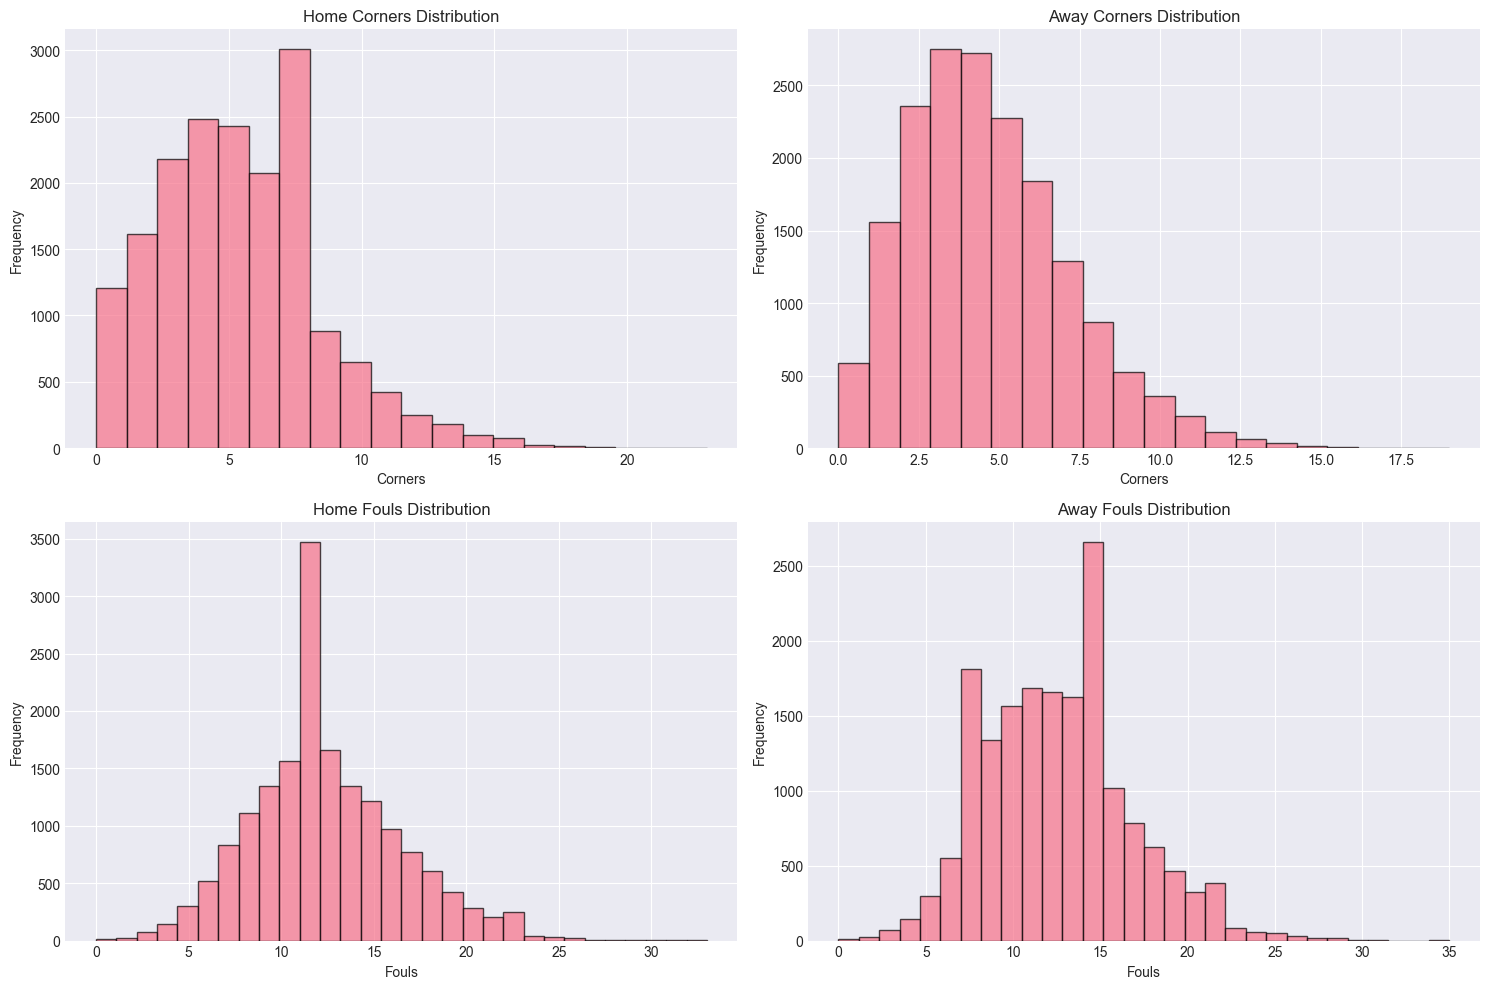

In [333]:
# Analyze corners and fouls
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].hist(fixture_stats['home_corners'].dropna(), bins=20, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Home Corners Distribution')
axes[0, 0].set_xlabel('Corners')
axes[0, 0].set_ylabel('Frequency')

axes[0, 1].hist(fixture_stats['away_corners'].dropna(), bins=20, edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Away Corners Distribution')
axes[0, 1].set_xlabel('Corners')
axes[0, 1].set_ylabel('Frequency')

axes[1, 0].hist(fixture_stats['home_fouls'].dropna(), bins=30, edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Home Fouls Distribution')
axes[1, 0].set_xlabel('Fouls')
axes[1, 0].set_ylabel('Frequency')

axes[1, 1].hist(fixture_stats['away_fouls'].dropna(), bins=30, edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Away Fouls Distribution')
axes[1, 1].set_xlabel('Fouls')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'corners_&_fouls_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

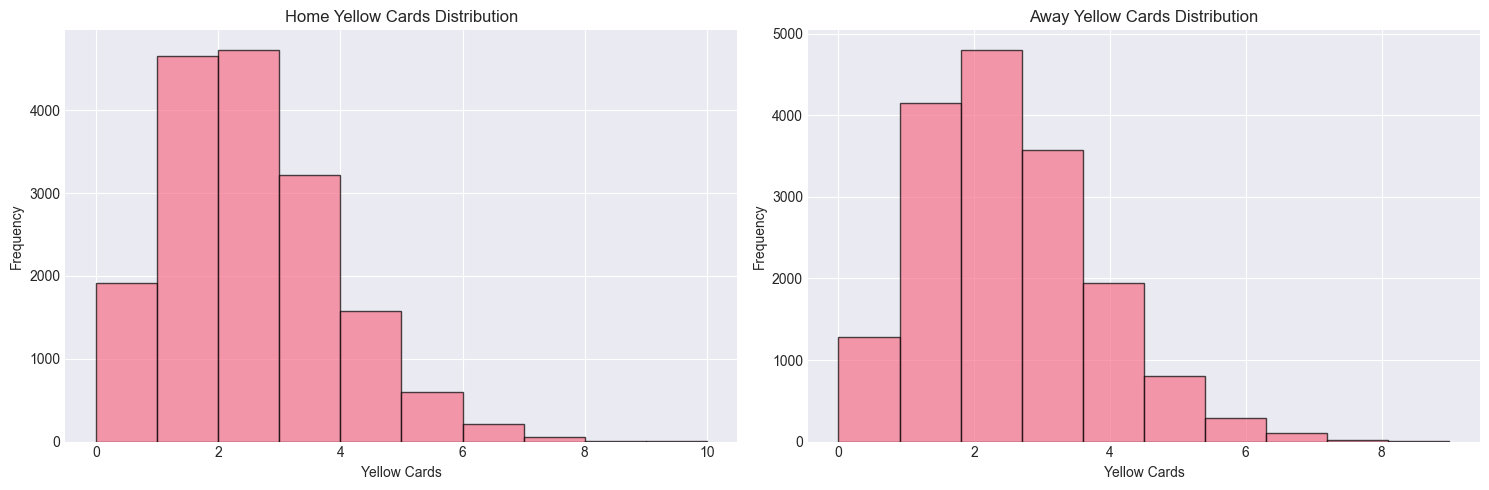

In [334]:
# Analyze yellow cards
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(fixture_stats['home_yellow_cards'].dropna(), bins=10, edgecolor='black', alpha=0.7)
axes[0].set_title('Home Yellow Cards Distribution')
axes[0].set_xlabel('Yellow Cards')
axes[0].set_ylabel('Frequency')

axes[1].hist(fixture_stats['away_yellow_cards'].dropna(), bins=10, edgecolor='black', alpha=0.7)
axes[1].set_title('Away Yellow Cards Distribution')
axes[1].set_xlabel('Yellow Cards')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'yellow_card_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

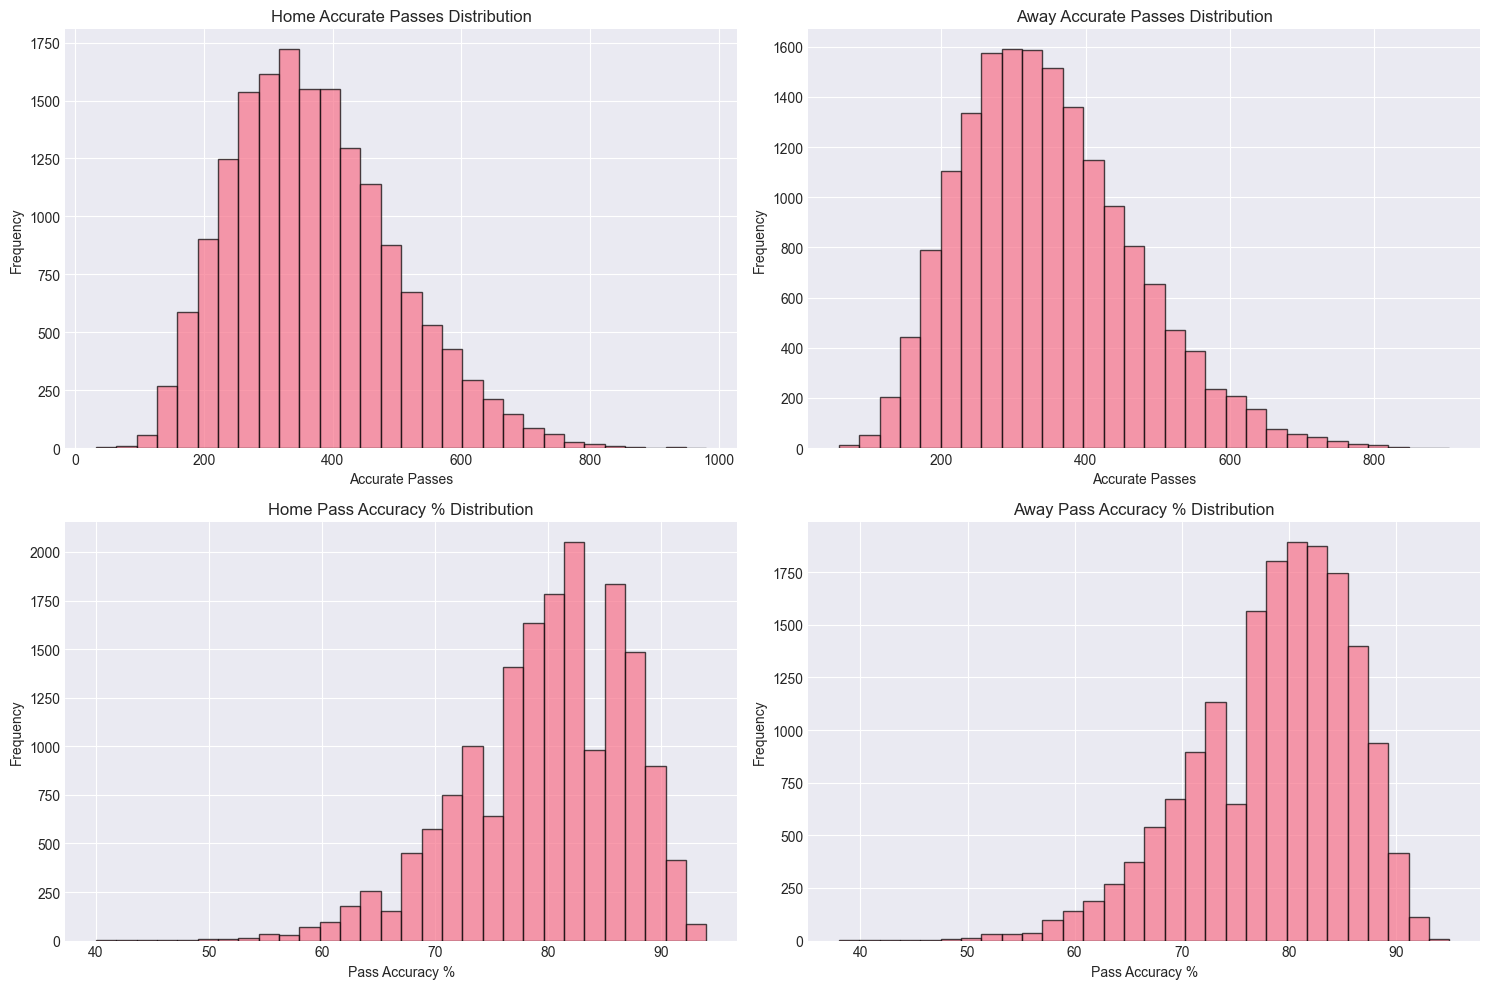

In [335]:
# Analyze passing statistics
fixture_stats['home_passes_percent_numeric'] = fixture_stats['home_passes_percent'].str.rstrip('%').astype('float')
fixture_stats['away_passes_percent_numeric'] = fixture_stats['away_passes_percent'].str.rstrip('%').astype('float')

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].hist(fixture_stats['home_passes_accurate'].dropna(), bins=30, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Home Accurate Passes Distribution')
axes[0, 0].set_xlabel('Accurate Passes')
axes[0, 0].set_ylabel('Frequency')

axes[0, 1].hist(fixture_stats['away_passes_accurate'].dropna(), bins=30, edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Away Accurate Passes Distribution')
axes[0, 1].set_xlabel('Accurate Passes')
axes[0, 1].set_ylabel('Frequency')

axes[1, 0].hist(fixture_stats['home_passes_percent_numeric'].dropna(), bins=30, edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Home Pass Accuracy % Distribution')
axes[1, 0].set_xlabel('Pass Accuracy %')
axes[1, 0].set_ylabel('Frequency')

axes[1, 1].hist(fixture_stats['away_passes_percent_numeric'].dropna(), bins=30, edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Away Pass Accuracy % Distribution')
axes[1, 1].set_xlabel('Pass Accuracy %')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'accurate_passes_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [336]:
# Compare home vs away statistics
stats_comparison = pd.DataFrame({
    'Home Shots on Goal': [fixture_stats['home_shots_on_goal'].mean()],
    'Away Shots on Goal': [fixture_stats['away_shots_on_goal'].mean()],
    'Home Total Shots': [fixture_stats['home_total_shots'].mean()],
    'Away Total Shots': [fixture_stats['away_total_shots'].mean()],
    'Home Corners': [fixture_stats['home_corners'].mean()],
    'Away Corners': [fixture_stats['away_corners'].mean()],
    'Home Fouls': [fixture_stats['home_fouls'].mean()],
    'Away Fouls': [fixture_stats['away_fouls'].mean()],
    'Home Yellow Cards': [fixture_stats['home_yellow_cards'].mean()],
    'Away Yellow Cards': [fixture_stats['away_yellow_cards'].mean()],
    'Home Possession': [fixture_stats['home_possession_numeric'].mean()],
    'Away Possession': [fixture_stats['away_possession_numeric'].mean()]
})

stats_comparison

,Home Shots on Goal,Away Shots on Goal,Home Total Shots,Away Total Shots,Home Corners,Away Corners,Home Fouls,Away Fouls,Home Yellow Cards,Away Yellow Cards,Home Possession,Away Possession
0,4.842,3.951,13.815,11.313,5.423,4.415,12.338,12.478,2.056,2.296,51.123,48.877


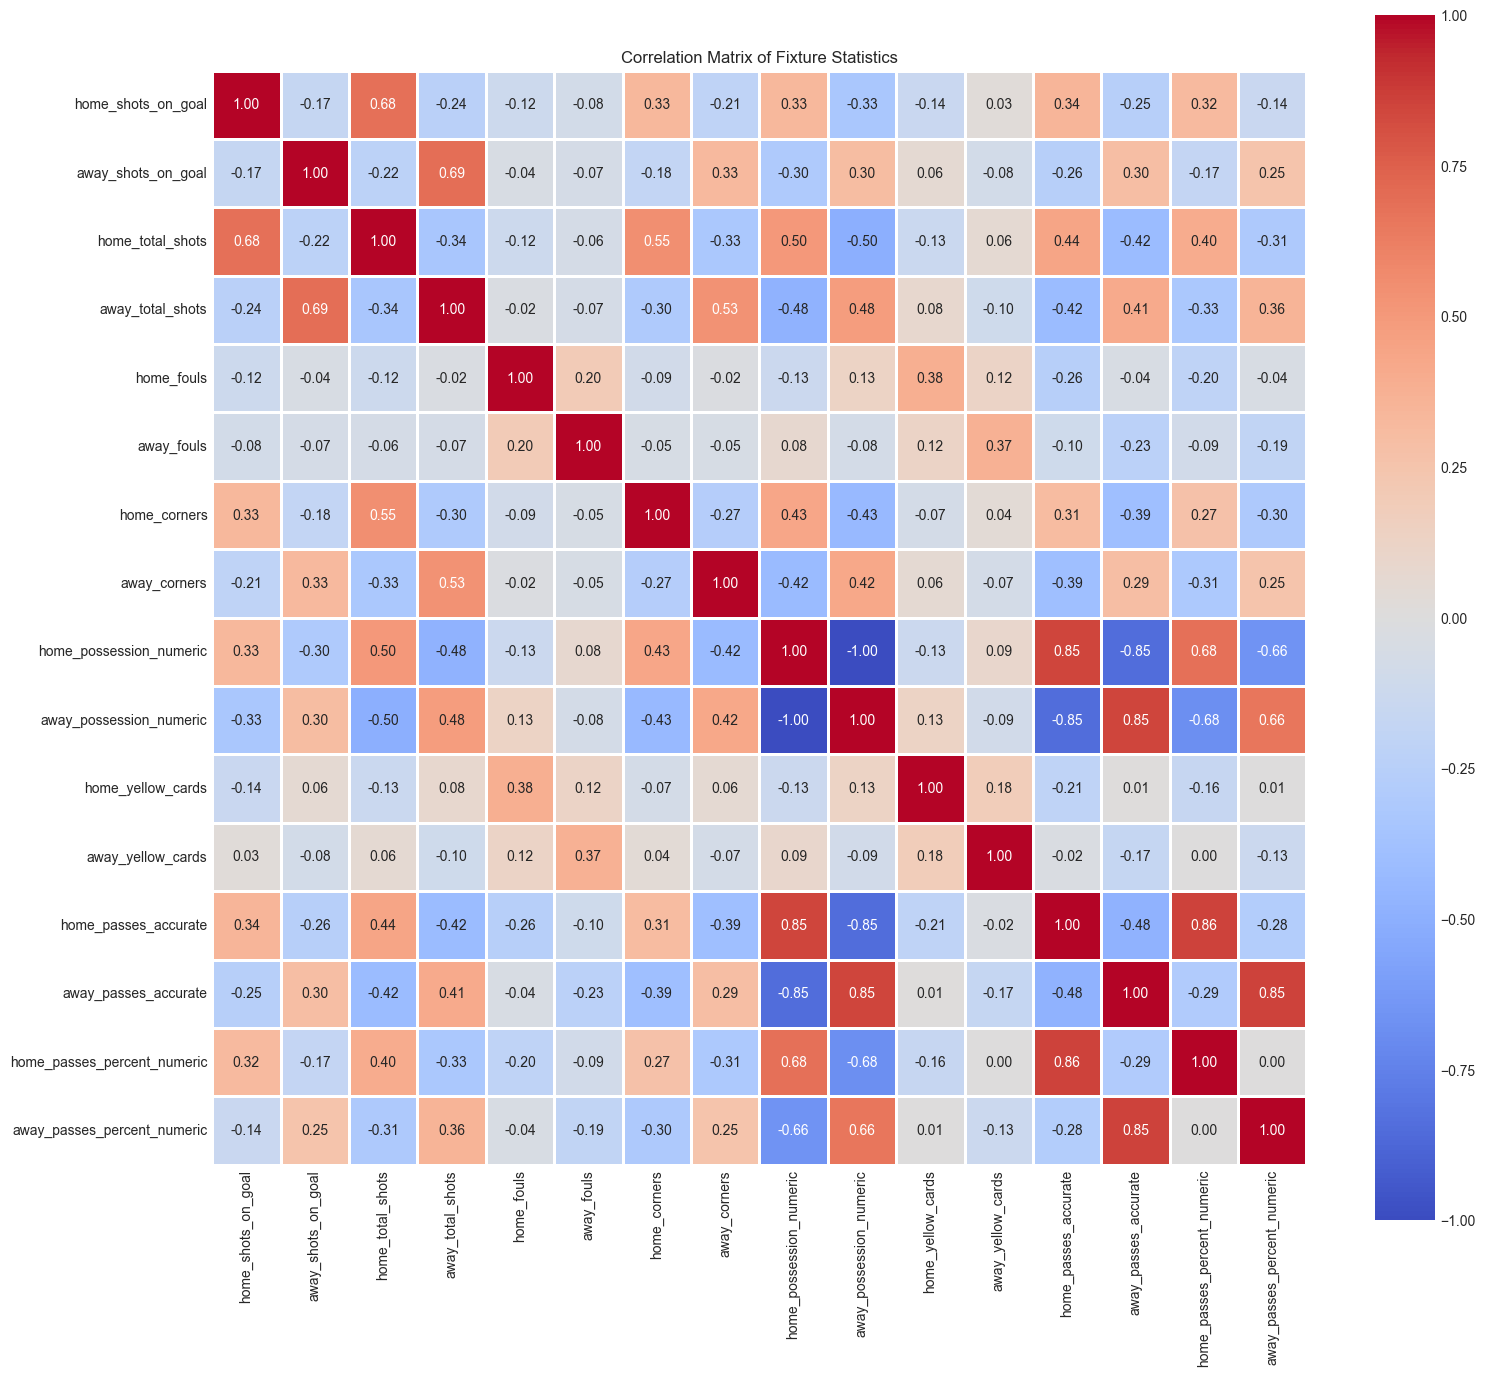

In [337]:
# Correlation matrix for fixture statistics
stats_cols = ['home_shots_on_goal', 'away_shots_on_goal', 'home_total_shots', 
              'away_total_shots', 'home_fouls', 'away_fouls', 'home_corners', 
              'away_corners', 'home_possession_numeric', 'away_possession_numeric',
              'home_yellow_cards', 'away_yellow_cards', 'home_passes_accurate', 
              'away_passes_accurate', 'home_passes_percent_numeric', 'away_passes_percent_numeric']

correlation_matrix = fixture_stats[stats_cols].corr()

plt.figure(figsize=(16, 14))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=1)
plt.title('Correlation Matrix of Fixture Statistics')
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'corr_mtx_fixture_stats.png', dpi=300, bbox_inches='tight')
plt.show()

In [338]:
# Analyze statistics by league
league_stats = fixture_stats.groupby('league_name').agg({
    'home_shots_on_goal': 'mean',
    'away_shots_on_goal': 'mean',
    'home_total_shots': 'mean',
    'away_total_shots': 'mean',
    'home_possession_numeric': 'mean',
    'away_possession_numeric': 'mean',
    'home_corners': 'mean',
    'away_corners': 'mean',
    'home_fouls': 'mean',
    'away_fouls': 'mean'
}).round(2)

league_stats.to_csv(TABLES_PATH / 'league_stats_TABLE.csv', index=False)
print(f"Saved cleaned dataset to '{TABLES_PATH}/df_merged_cleaned.csv'")

league_stats

Saved cleaned dataset to '/Users/vishalchaudhary/Desktop/Football_Project_FINAL/DOMAIN_APPLICATIONS_PROJECT/results/tables/df_merged_cleaned.csv'


,home_shots_on_goal,away_shots_on_goal,home_total_shots,away_total_shots,home_possession_numeric,away_possession_numeric,home_corners,away_corners,home_fouls,away_fouls
league_name,,,,,,,,,,
Bundesliga,5.140,4.260,14.300,11.950,51.290,48.710,5.280,4.500,11.720,12.090
Eredivisie,5.420,4.330,14.910,12.050,51.390,48.610,5.670,4.560,10.300,10.750
La Liga,4.540,3.560,13.100,10.390,51.260,48.740,5.180,4.120,13.360,13.200
Ligue 1,4.660,3.900,13.290,11.100,50.960,49.040,5.220,4.300,12.450,12.740
Premier League,4.820,4.090,13.930,11.540,50.860,49.140,5.730,4.680,10.540,10.720
Primeira Liga,4.470,3.780,13.270,11.220,51.340,48.660,5.530,4.680,15.350,14.960
Serie A,4.760,4.020,14.310,12.090,50.300,49.700,5.410,4.530,12.930,13.320
UEFA Champions League,5.080,4.050,13.940,11.220,51.210,48.790,5.350,4.190,12.210,12.200
UEFA Europa Conference League,4.960,3.670,13.640,10.160,52.190,47.810,5.580,4.090,11.970,11.990


In [339]:
# Analyze statistics by season
season_stats = fixture_stats.groupby('season').agg({
    'home_shots_on_goal': 'mean',
    'away_shots_on_goal': 'mean',
    'home_total_shots': 'mean',
    'away_total_shots': 'mean',
    'home_possession_numeric': 'mean',
    'away_possession_numeric': 'mean',
    'home_corners': 'mean',
    'away_corners': 'mean'
}).round(2)

season_stats

,home_shots_on_goal,away_shots_on_goal,home_total_shots,away_total_shots,home_possession_numeric,away_possession_numeric,home_corners,away_corners
season,,,,,,,,
2018,4.970,3.910,14.170,11.390,50.970,49.030,5.600,4.510
2019,4.790,3.960,13.760,11.350,50.980,49.020,5.530,4.550
2020,4.490,3.920,12.680,11.070,50.670,49.330,5.060,4.420
2021,4.710,3.940,13.690,11.270,51.350,48.650,5.340,4.380
2022,4.900,3.930,13.930,11.340,51.160,48.840,5.400,4.340
2023,5.160,4.040,14.580,11.440,51.570,48.430,5.600,4.310


### 7. LineUps Data

In [340]:
# Data Types and Missing Values
print("DATA TYPES & MISSING VALUES")

info_df = pd.DataFrame({
    'Column': lineups.columns,
    'Type': lineups.dtypes.values,
    'Non-Null': lineups.count().values,
    'Null': lineups.isnull().sum().values,
    'Null %': (lineups.isnull().sum() / len(lineups) * 100).values
})

display(info_df)

print(f"\nTotal Missing Values: {lineups.isnull().sum().sum():,}")


DATA TYPES & MISSING VALUES


,Column,Type,Non-Null,Null,Null %
0,fixture_id,int64,18011,0,0.000
1,league_id,int64,18011,0,0.000
2,league_name,object,18011,0,0.000
3,season,int64,18011,0,0.000
4,date,object,18011,0,0.000
5,home_team_id,int64,18011,0,0.000
6,home_team_name,object,18011,0,0.000
7,away_team_id,int64,18011,0,0.000
8,away_team_name,object,18011,0,0.000
9,home_formation,object,17892,119,0.661



Total Missing Values: 65,896


FORMATION ANALYSIS - HOME AND AWAY TEAMS

Top 10 Home Formations:
home_formation
4-2-3-1    4619
4-3-3      3908
4-4-2      2340
3-4-2-1    1225
3-5-2      1210
4-1-4-1     825
3-4-3       702
3-4-1-2     585
4-3-1-2     510
5-3-2       472
Name: count, dtype: int64

Top 10 Away Formations:
away_formation
4-2-3-1    4377
4-3-3      3767
4-4-2      2169
3-4-2-1    1299
3-5-2      1287
4-1-4-1     824
3-4-3       711
5-3-2       605
3-4-1-2     595
4-3-1-2     499
Name: count, dtype: int64


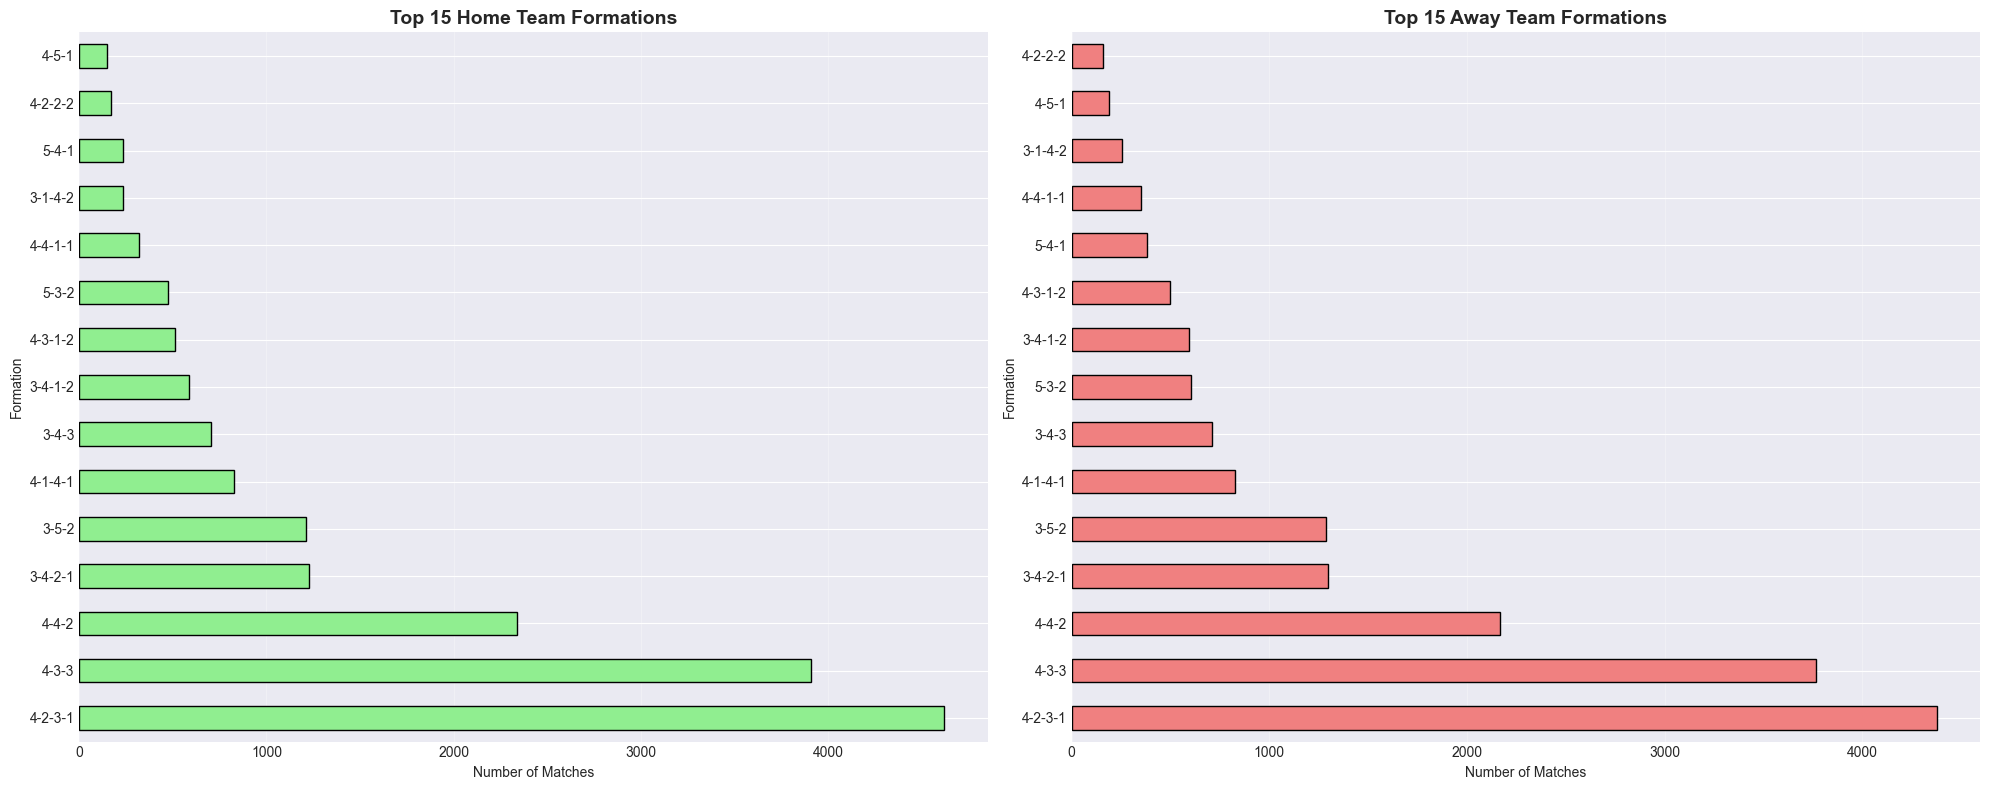

In [341]:
# FORMATION ANALYSIS - HOME AND AWAY TEAMS

print("FORMATION ANALYSIS - HOME AND AWAY TEAMS")

# Get value counts
home_formations = lineups['home_formation'].value_counts()
away_formations = lineups['away_formation'].value_counts()

# Print top 10 formations
print("\nTop 10 Home Formations:")
print(home_formations.head(10))

print("\nTop 10 Away Formations:")
print(away_formations.head(10))

# Visualize in a single figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Home formations
home_formations.head(15).plot(
    kind='barh', ax=axes[0], color='lightgreen', edgecolor='black'
)
axes[0].set_title('Top 15 Home Team Formations', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Matches')
axes[0].set_ylabel('Formation')
axes[0].grid(axis='x', alpha=0.3)

# Away formations
away_formations.head(15).plot(
    kind='barh', ax=axes[1], color='lightcoral', edgecolor='black'
)
axes[1].set_title('Top 15 Away Team Formations', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Matches')
axes[1].set_ylabel('Formation')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'FORMATION_ANALYSIS.png', dpi=300, bbox_inches='tight')

plt.show()


In [342]:
# Coach Analysis
print("COACH ANALYSIS")

# Most common coaches
home_coaches = lineups['home_coach_name'].value_counts()
away_coaches = lineups['away_coach_name'].value_counts()

# Combine home and away
all_coaches = pd.concat([
    lineups['home_coach_name'].value_counts(),
    lineups['away_coach_name'].value_counts()
]).groupby(level=0).sum().sort_values(ascending=False)

print("\nTop 20 Coaches (by number of matches):")
print(all_coaches.head(20))



COACH ANALYSIS

Top 20 Coaches (by number of matches):
J. Klopp            289
C. Ancelotti        280
S. Inzaghi          278
D. Simeone          278
G. Gasperini        274
Unai Emery          266
S. Pioli            248
E. ten Hag          245
Imanol Alguacil     242
T. Tuchel           241
M. Pellegrini       234
M. Sarri            228
José Mourinho       228
C. Streich          222
Sérgio Conceição    220
M. Rose             216
D. Moyes            207
S. Dyche            205
José Bordalás       205
Mikel Arteta        205
Name: count, dtype: int64


In [343]:
# Starting XI and Substitutes Analysis
print("STARTING XI & SUBSTITUTES ANALYSIS")

print("\nHome Team:")
print(f"  Average Starting XI: {lineups['home_startXI_count'].mean():.2f}")
print(f"  Average Substitutes: {lineups['home_subs_count'].mean():.2f}")

print("\nAway Team:")
print(f"  Average Starting XI: {lineups['away_startXI_count'].mean():.2f}")
print(f"  Average Substitutes: {lineups['away_subs_count'].mean():.2f}")


STARTING XI & SUBSTITUTES ANALYSIS

Home Team:
  Average Starting XI: 11.00
  Average Substitutes: 9.36

Away Team:
  Average Starting XI: 11.00
  Average Substitutes: 9.28


In [344]:
#  Formation Comparison - Home vs Away
print("FORMATION COMPARISON: HOME VS AWAY")

# Top formations
top_formations = pd.DataFrame({
    'Home': home_formations.head(10),
    'Away': away_formations.head(10)
})

print("\nTop 10 Formations Comparison:")
display(top_formations)

# Check if teams play differently at home vs away
home_away_same = (lineups['home_formation'] == lineups['away_formation']).sum()
print(f"\nMatches where both teams used same formation: {home_away_same} ({home_away_same/len(lineups)*100:.1f}%)")



FORMATION COMPARISON: HOME VS AWAY

Top 10 Formations Comparison:


,Home,Away
3-4-1-2,585,595
3-4-2-1,1225,1299
3-4-3,702,711
3-5-2,1210,1287
4-1-4-1,825,824
4-2-3-1,4619,4377
4-3-1-2,510,499
4-3-3,3908,3767
4-4-2,2340,2169
5-3-2,472,605



Matches where both teams used same formation: 3248 (18.0%)


In [345]:
#  League-Specific Formation Patterns
print("LEAGUE-SPECIFIC FORMATION PATTERNS")

# Most common formation per league
league_formations = lineups.groupby('league_name')['home_formation'].agg(lambda x: x.mode()[0] if len(x.mode()) > 0 else None)

print("\nMost Common Formation by League:")
print(league_formations)


LEAGUE-SPECIFIC FORMATION PATTERNS

Most Common Formation by League:
league_name
Bundesliga                       4-2-3-1
Eredivisie                         4-3-3
La Liga                            4-4-2
Ligue 1                          4-2-3-1
Premier League                   4-2-3-1
Primeira Liga                    4-2-3-1
Serie A                            3-5-2
UEFA Champions League              4-3-3
UEFA Europa Conference League      4-3-3
UEFA Europa League               4-2-3-1
Name: home_formation, dtype: object


In [346]:
#  Missing Data Analysis
print("MISSING DATA ANALYSIS")

# Check which matches have missing formation data
missing_home_formation = lineups['home_formation'].isnull().sum()
missing_away_formation = lineups['away_formation'].isnull().sum()
missing_coach_home = lineups['home_coach_name'].isnull().sum()
missing_coach_away = lineups['away_coach_name'].isnull().sum()

print(f"\nMissing home formation: {missing_home_formation} ({missing_home_formation/len(lineups)*100:.2f}%)")
print(f"Missing away formation: {missing_away_formation} ({missing_away_formation/len(lineups)*100:.2f}%)")
print(f"Missing home coach: {missing_coach_home} ({missing_coach_home/len(lineups)*100:.2f}%)")
print(f"Missing away coach: {missing_coach_away} ({missing_coach_away/len(lineups)*100:.2f}%)")



MISSING DATA ANALYSIS

Missing home formation: 119 (0.66%)
Missing away formation: 158 (0.88%)
Missing home coach: 79 (0.44%)
Missing away coach: 116 (0.64%)


In [347]:
#  Data Quality Check
print("DATA QUALITY CHECK")

# Check for any anomalies
print("\nStarting XI Count Distribution:")
print(f"  Min (Home): {lineups['home_startXI_count'].min()}")
print(f"  Max (Home): {lineups['home_startXI_count'].max()}")
print(f"  Min (Away): {lineups['away_startXI_count'].min()}")
print(f"  Max (Away): {lineups['away_startXI_count'].max()}")

# Flag unusual values (standard is 11 players)
unusual_home = lineups[lineups['home_startXI_count'] != 11]
unusual_away = lineups[lineups['away_startXI_count'] != 11]

DATA QUALITY CHECK

Starting XI Count Distribution:
  Min (Home): 11
  Max (Home): 11
  Min (Away): 11
  Max (Away): 11


### 7. Data Quality Check 

In [348]:
#  Data Quality Check

print("DATA QUALITY ASSESSMENT")

def check_quality(df, name):
    print(f"\n {name}")
    print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} cols")
    
    # Missing values
    missing = df.isnull().sum()
    if missing.sum() > 0:
        missing_pct = (missing / len(df) * 100).round(2)
        missing_df = pd.DataFrame({
            'Count': missing[missing > 0],
            'Percentage': missing_pct[missing > 0]
        }).sort_values('Count', ascending=False)
        print(f"\n  Missing Values:")
        display(missing_df.head(10))
    else:
        print("\n No missing values!")
    
    # Duplicates
    dups = df.duplicated().sum()
    print(f"\nDuplicates: {dups:,}")
    
    return missing.sum()


DATA QUALITY ASSESSMENT


In [349]:
# Check all datasets
check_quality(df_fixtures, "HISTORICAL FIXTURES")



 HISTORICAL FIXTURES
Shape: 18,894 rows x 21 cols

  Missing Values:


,Count,Percentage
referee,206,1.090
venue_city,80,0.420
home_score_halftime,7,0.040
away_score_halftime,7,0.040
venue_name,2,0.010



Duplicates: 0


np.int64(302)

In [350]:
check_quality(df_2024_test, "2024 TEST SET")



 2024 TEST SET
Shape: 3,342 rows x 22 cols

  Missing Values:


,Count,Percentage
home_score_halftime,2,0.060
away_score_halftime,2,0.060
referee,1,0.030



Duplicates: 0


np.int64(5)

In [351]:
check_quality(df_squad, "TEAM STATISTICS")


 TEAM STATISTICS
Shape: 78,547 rows x 11 cols

  Missing Values:


,Count,Percentage
player_number,1380,1.760
player_age,549,0.700
player_position,75,0.100



Duplicates: 0


np.int64(2004)

In [352]:
check_quality(df_standings, "STANDINGS")



 STANDINGS
Shape: 862 rows x 35 cols

  Missing Values:


,Count,Percentage
description,426,49.420
status,142,16.470



Duplicates: 0


np.int64(568)

In [353]:
check_quality(df_h2h, "H2H DATA")



 H2H DATA
Shape: 18,894 rows x 38 cols

  Missing Values:


,Count,Percentage
h2h_days_since_last_meeting,4515,23.900
h2h_last_result,4515,23.900
referee,206,1.090
venue_city,80,0.420
home_score_halftime,7,0.040
away_score_halftime,7,0.040
venue_name,2,0.010



Duplicates: 0


np.int64(9332)

In [354]:
check_quality(df_squad, "SQUAD DATA")



 SQUAD DATA
Shape: 78,547 rows x 11 cols

  Missing Values:


,Count,Percentage
player_number,1380,1.760
player_age,549,0.700
player_position,75,0.100



Duplicates: 0


np.int64(2004)

In [355]:
check_quality(df_players_clean, "TOP 500 PLAYERS (CLEANED)")



 TOP 500 PLAYERS (CLEANED)
Shape: 10,266 rows x 23 cols

  Missing Values:


,Count,Percentage
appearances,10266,100.000
assists,5667,55.200
shots_on,3414,33.260
dribbles_success,2314,22.540
shots_total,2290,22.310
key_passes,2170,21.140
interceptions,2099,20.450
tackles_total,1596,15.550
fouls_committed,1475,14.370
duels_won,858,8.360



Duplicates: 0


np.int64(33390)

In [356]:
check_quality(df_injuries, "INJURIES DATA")


 INJURIES DATA
Shape: 37,198 rows x 9 cols

  Missing Values:


,Count,Percentage
age,37198,100.000
player_name,2,0.010



Duplicates: 2


np.int64(37200)

### 7. Create Target Variable

In [357]:

# Create Target Variable & Basic Features

print("CREATING TARGET VARIABLE & FEATURES")

def create_target(df):
    """Create match outcome target variable"""
    conditions = [
        df['home_goals'] > df['away_goals'],
        df['home_goals'] == df['away_goals'],
        df['home_goals'] < df['away_goals']
    ]
    choices = ['H', 'D', 'A']
    df['match_outcome'] = np.select(conditions, choices, default='Unknown')
    
    # Numeric encoding
    outcome_map = {'H': 0, 'D': 1, 'A': 2}
    df['target'] = df['match_outcome'].map(outcome_map)
    
    return df

# Apply to both datasets
df_fixtures = create_target(df_fixtures)
df_2024_test = create_target(df_2024_test)

print(" Target variable created!")
print("\n Outcome Distribution (2018-2023):")
outcome_dist = df_fixtures['match_outcome'].value_counts()
print(outcome_dist)
print("\nPercentages:")
for outcome, count in outcome_dist.items():
    pct = count / len(df_fixtures) * 100
    print(f"   {outcome}: {pct:.2f}%")

# Create additional basic features
print("\n Creating basic features...")

df_fixtures['total_goals'] = df_fixtures['home_goals'] + df_fixtures['away_goals']
df_fixtures['goal_diff'] = df_fixtures['home_goals'] - df_fixtures['away_goals']
df_fixtures['home_clean_sheet'] = (df_fixtures['away_goals'] == 0).astype(int)
df_fixtures['away_clean_sheet'] = (df_fixtures['home_goals'] == 0).astype(int)
df_fixtures['both_scored'] = ((df_fixtures['home_goals'] > 0) & (df_fixtures['away_goals'] > 0)).astype(int)

# Same for 2024 test
df_2024_test['total_goals'] = df_2024_test['home_goals'] + df_2024_test['away_goals']
df_2024_test['goal_diff'] = df_2024_test['home_goals'] - df_2024_test['away_goals']

# Temporal features
df_fixtures['year'] = df_fixtures['date'].dt.year
df_fixtures['month'] = df_fixtures['date'].dt.month
df_fixtures['month_name'] = df_fixtures['date'].dt.month_name()
df_fixtures['day_of_week'] = df_fixtures['date'].dt.day_name()

print(" Basic features created!")


CREATING TARGET VARIABLE & FEATURES
 Target variable created!

 Outcome Distribution (2018-2023):
match_outcome
H    8413
A    5924
D    4557
Name: count, dtype: int64

Percentages:
   H: 44.53%
   A: 31.35%
   D: 24.12%

 Creating basic features...
 Basic features created!


### 8. Target Variable Analysis

TARGET VARIABLE ANALYSIS - Overall Distribution


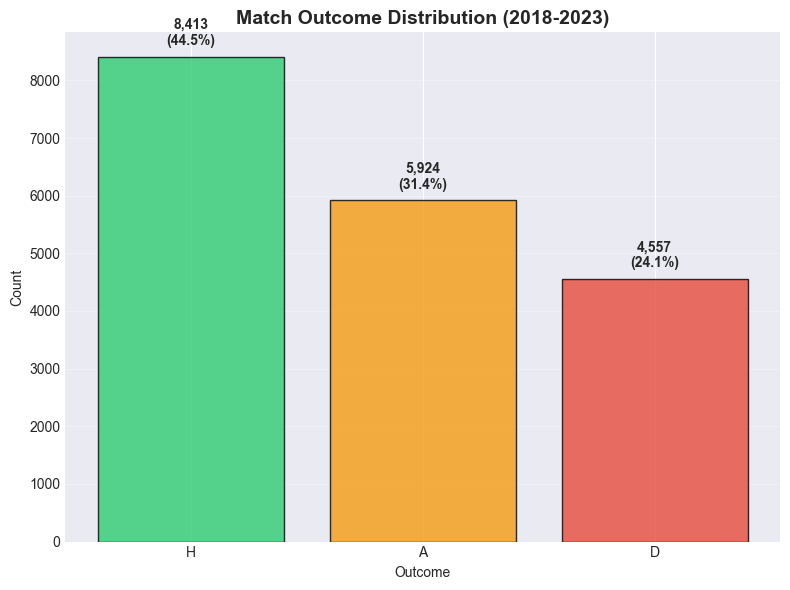

In [358]:
# Match Outcome Distribution
print("TARGET VARIABLE ANALYSIS - Overall Distribution")

plt.figure(figsize=(8, 6))
colors = ['#2ecc71', '#f39c12', '#e74c3c']

outcome_counts = df_fixtures['match_outcome'].value_counts()
plt.bar(outcome_counts.index, outcome_counts.values, color=colors, alpha=0.8, edgecolor='black')

plt.title('Match Outcome Distribution (2018-2023)', fontsize=14, fontweight='bold')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.3)

for i, v in enumerate(outcome_counts.values):
    pct = v / len(df_fixtures) * 100
    plt.text(i, v + 200, f'{v:,}\n({pct:.1f}%)', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'match_outcome_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


TARGET VARIABLE ANALYSIS - Outcome % by League


<Figure size 1000x600 with 0 Axes>

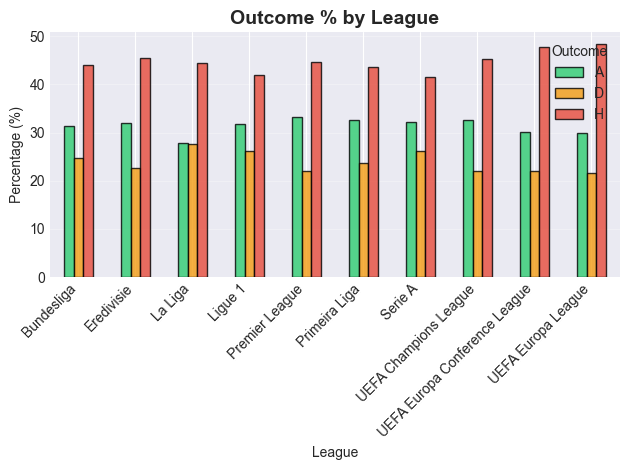

In [359]:
# Outcome Percentage by League
print("TARGET VARIABLE ANALYSIS - Outcome % by League")

plt.figure(figsize=(10, 6))
colors = ['#2ecc71', '#f39c12', '#e74c3c']

outcome_by_league = pd.crosstab(df_fixtures['league_name'], df_fixtures['match_outcome'], normalize='index') * 100
outcome_by_league.plot(kind='bar', color=colors, alpha=0.8, edgecolor='black')

plt.title('Outcome % by League', fontsize=14, fontweight='bold')
plt.xlabel('League')
plt.ylabel('Percentage (%)')
plt.legend(title='Outcome')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'outcome_by_league.png', dpi=300, bbox_inches='tight')
plt.show()


TARGET VARIABLE ANALYSIS - Outcome Trends Over Seasons


<Figure size 1000x600 with 0 Axes>

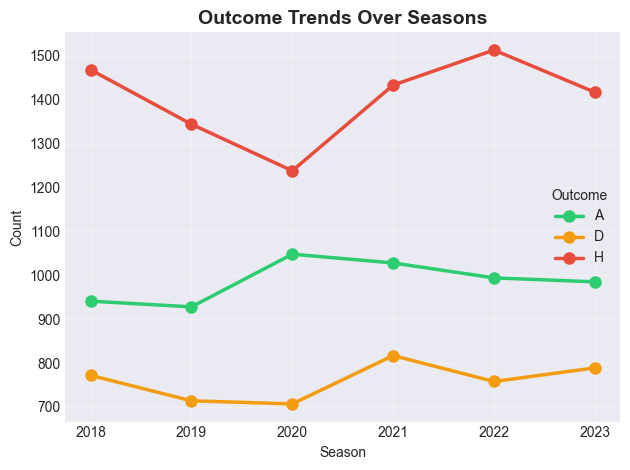

In [360]:
print("TARGET VARIABLE ANALYSIS - Outcome Trends Over Seasons")

plt.figure(figsize=(10, 6))
colors = ['#2ecc71', '#f39c12', '#e74c3c']

outcome_by_season = pd.crosstab(df_fixtures['season'], df_fixtures['match_outcome'])
outcome_by_season.plot(kind='line', marker='o', linewidth=2.5, markersize=8, color=colors)

plt.title('Outcome Trends Over Seasons', fontsize=14, fontweight='bold')
plt.xlabel('Season')
plt.ylabel('Count')
plt.legend(title='Outcome')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'outcome_trends_over_seasons.png', dpi=300, bbox_inches='tight')
plt.show()


### 9. Goal Analysis

In [361]:

# Section 9: Goals Analysis
print("GOALS ANALYSIS")

print(f" Goals Statistics:")
print(f"  Avg Home Goals: {df_fixtures['home_goals'].mean():.3f}")
print(f"  Avg Away Goals: {df_fixtures['away_goals'].mean():.3f}")
print(f"  Avg Total Goals: {df_fixtures['total_goals'].mean():.3f}")
print(f"  Home Advantage: +{df_fixtures['home_goals'].mean() - df_fixtures['away_goals'].mean():.3f} goals")

GOALS ANALYSIS
 Goals Statistics:
  Avg Home Goals: 1.572
  Avg Away Goals: 1.248
  Avg Total Goals: 2.819
  Home Advantage: +0.324 goals


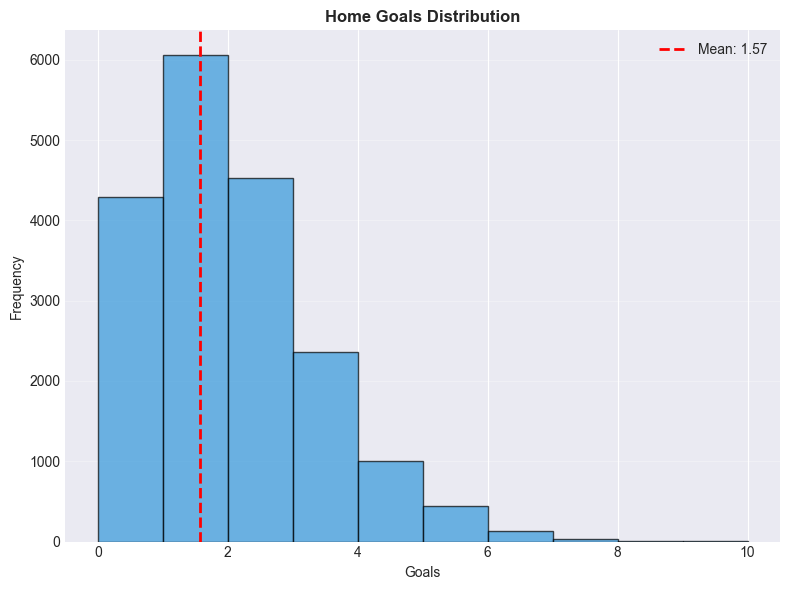

In [362]:
# Home Goals Distribution
plt.figure(figsize=(8, 6))
plt.hist(df_fixtures['home_goals'], bins=range(0, 11), color='#3498db', alpha=0.7, edgecolor='black')
plt.axvline(df_fixtures['home_goals'].mean(), color='red', linestyle='--', linewidth=2,
            label=f"Mean: {df_fixtures['home_goals'].mean():.2f}")
plt.title('Home Goals Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Goals')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'home_goals_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


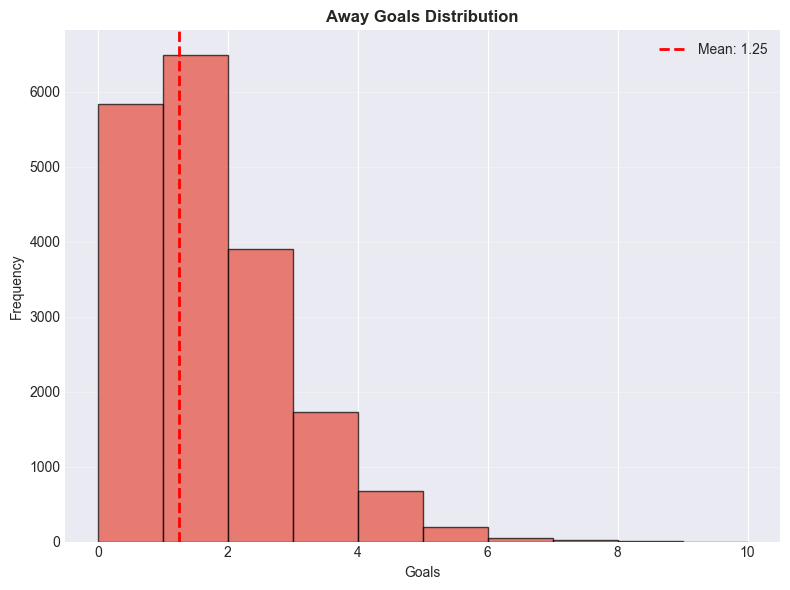

In [363]:
# Away Goals Distribution
plt.figure(figsize=(8, 6))
plt.hist(df_fixtures['away_goals'], bins=range(0, 11), color='#e74c3c', alpha=0.7, edgecolor='black')
plt.axvline(df_fixtures['away_goals'].mean(), color='red', linestyle='--', linewidth=2,
            label=f"Mean: {df_fixtures['away_goals'].mean():.2f}")
plt.title('Away Goals Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Goals')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'away_goals_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


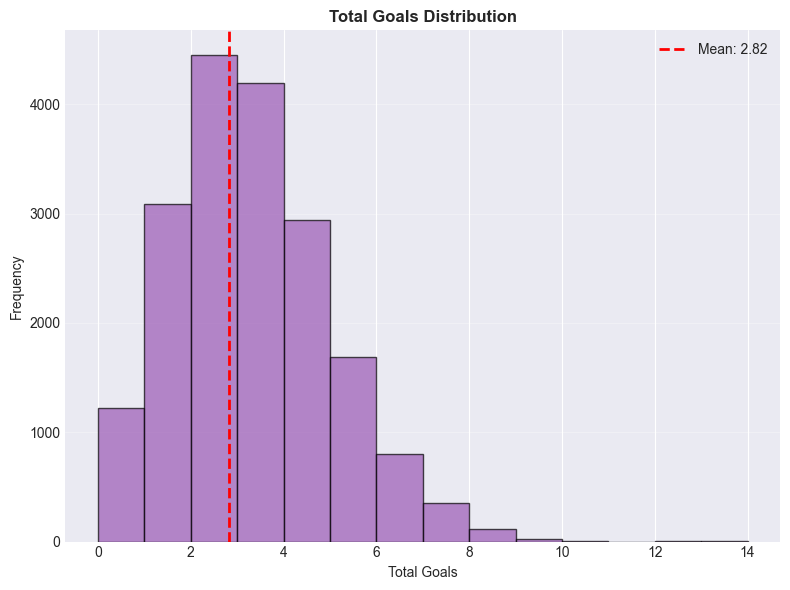

In [364]:
# Total Goals Distribution
plt.figure(figsize=(8, 6))
plt.hist(df_fixtures['total_goals'], bins=range(0, 15), color='#9b59b6', alpha=0.7, edgecolor='black')
plt.axvline(df_fixtures['total_goals'].mean(), color='red', linestyle='--', linewidth=2,
            label=f"Mean: {df_fixtures['total_goals'].mean():.2f}")
plt.title('Total Goals Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Total Goals')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'total_goals_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


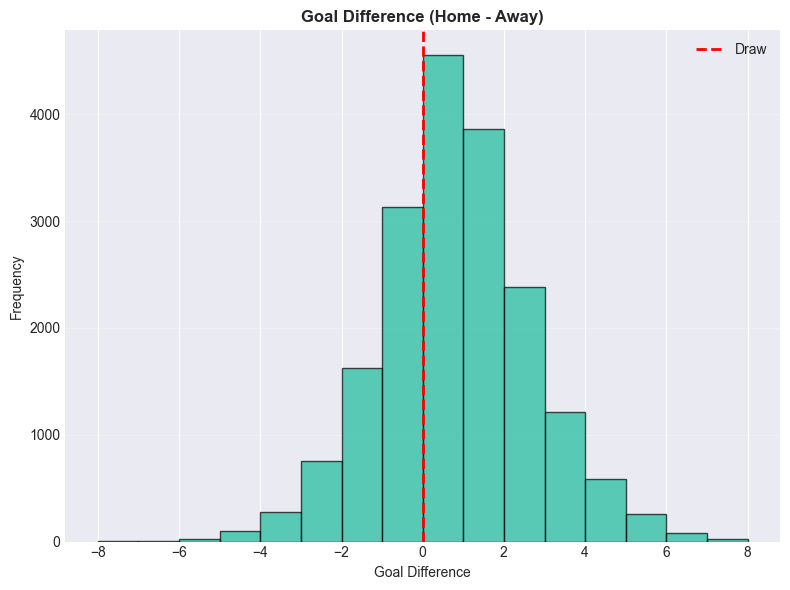

In [365]:
# Goal Difference (Home - Away)
plt.figure(figsize=(8, 6))
plt.hist(df_fixtures['goal_diff'], bins=range(-8, 9), color='#1abc9c', alpha=0.7, edgecolor='black')
plt.axvline(0, color='red', linestyle='--', linewidth=2, label='Draw')
plt.title('Goal Difference (Home - Away)', fontsize=12, fontweight='bold')
plt.xlabel('Goal Difference')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'goal_difference_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


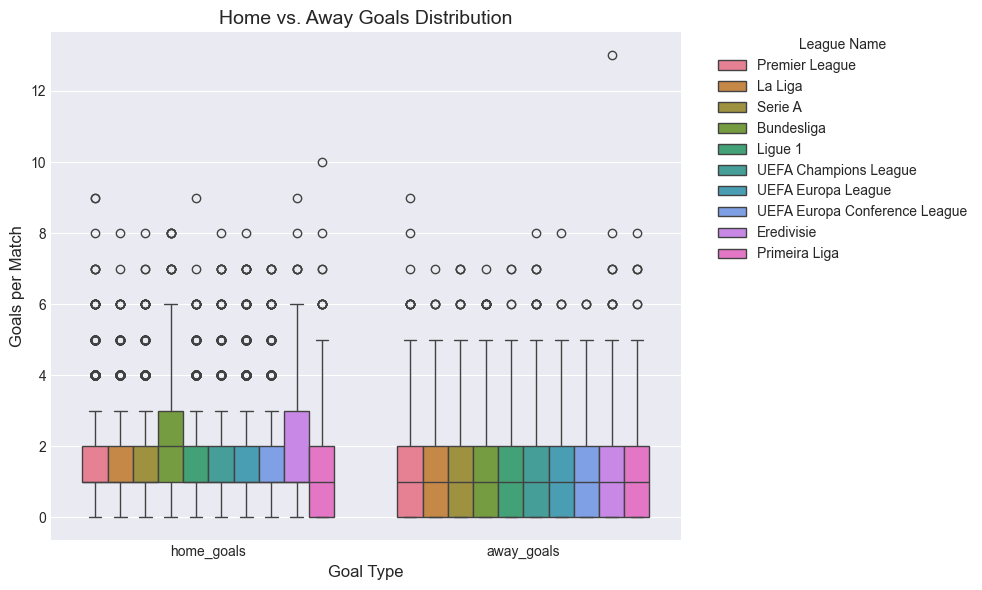

In [366]:
# Melt for plotting
goals_melted = pd.melt(
    df_fixtures,
    id_vars=['league_name'],
    value_vars=['home_goals', 'away_goals'],
    var_name='Goal Type',
    value_name='Goals'
)

# Set figure size for better spacing
plt.figure(figsize=(10, 6))

# Create boxplot
sns.boxplot(
    data=goals_melted,
    x='Goal Type',
    y='Goals',
    hue='league_name',
    showfliers=True  # Keep outliers visible
)

# Title and labels
plt.title('Home vs. Away Goals Distribution', fontsize=14)
plt.xlabel('Goal Type', fontsize=12)
plt.ylabel('Goals per Match', fontsize=12)

# Move legend outside the plot
plt.legend(
    title='League Name',
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0.
)

# Tight layout to prevent overlap
plt.tight_layout()

# Save and show
plt.savefig(FIGURES_PATH / 'home_away_goals_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()


Fixtures columns: ['fixture_id', 'date', 'timestamp', 'league_id', 'league_name', 'season', 'round', 'home_team_id', 'home_team_name', 'away_team_id', 'away_team_name', 'home_goals', 'away_goals', 'home_score_halftime', 'away_score_halftime', 'home_score_fulltime', 'away_score_fulltime', 'venue_name', 'venue_city', 'referee', 'status', 'match_outcome', 'target', 'total_goals', 'goal_diff', 'home_clean_sheet', 'away_clean_sheet', 'both_scored', 'year', 'month', 'month_name', 'day_of_week']
Players columns: ['season', 'league', 'player_id', 'player_name', 'age', 'nationality', 'team', 'position', 'appearances', 'minutes', 'rating', 'goals_total', 'assists', 'shots_total', 'shots_on', 'passes_total', 'key_passes', 'tackles_total', 'interceptions', 'duels_total', 'duels_won', 'dribbles_success', 'fouls_committed']
Merged data shape: (599283, 9)
Columns in merged data: ['fixture_id', 'season', 'home_team_name', 'match_outcome', 'team', 'position', 'rating', 'team_type', 'away_team_name']


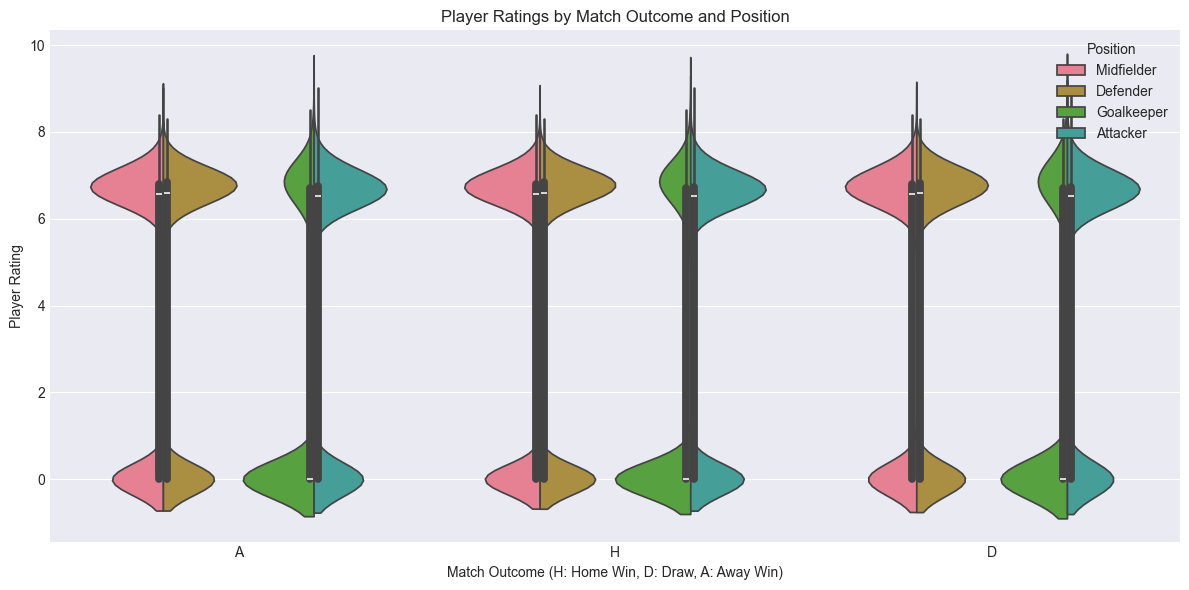

In [367]:
# Step 1: Verify columns
print("Fixtures columns:", df_fixtures.columns.tolist())
print("Players columns:", df_players.columns.tolist())

# Step 2: Derive match_outcome in df_fixtures
df_fixtures['match_outcome'] = np.where(df_fixtures['home_goals'] > df_fixtures['away_goals'], 'H',
                                        np.where(df_fixtures['home_goals'] < df_fixtures['away_goals'], 'A', 'D'))

# Step 3: Prepare player data (keep position)
# Instead of aggregating to team level, merge player-level data to retain position
# Merge df_players with df_fixtures for home and away teams separately
# Home team merge
df_home = pd.merge(
    df_fixtures[['fixture_id', 'season', 'home_team_name', 'match_outcome']],
    df_players[['season', 'team', 'position', 'rating']],
    left_on=['home_team_name', 'season'],
    right_on=['team', 'season'],
    how='inner'
)
df_home['team_type'] = 'Home'

# Away team merge
df_away = pd.merge(
    df_fixtures[['fixture_id', 'season', 'away_team_name', 'match_outcome']],
    df_players[['season', 'team', 'position', 'rating']],
    left_on=['away_team_name', 'season'],
    right_on=['team', 'season'],
    how='inner'
)
df_away['team_type'] = 'Away'

# Combine home and away
df_merged = pd.concat([df_home, df_away], ignore_index=True)

# Step 4: Check merge result
print("Merged data shape:", df_merged.shape)
print("Columns in merged data:", df_merged.columns.tolist())
if df_merged.empty:
    print("Warning: Merge resulted in empty DataFrame. Check team name consistency.")
    print("Fixtures teams (home):", df_fixtures['home_team_name'].unique()[:5])
    print("Players teams:", df_players['team'].unique()[:5])

# Step 5: Plot violin plot
plt.figure(figsize=(12, 6))
sns.violinplot(data=df_merged, x='match_outcome', y='rating', hue='position', split=True)
plt.title('Player Ratings by Match Outcome and Position')
plt.xlabel('Match Outcome (H: Home Win, D: Draw, A: Away Win)')
plt.ylabel('Player Rating')
plt.legend(title='Position', loc='upper right')
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'player_ratings_violinplot.png', dpi=300, bbox_inches='tight')
plt.show()

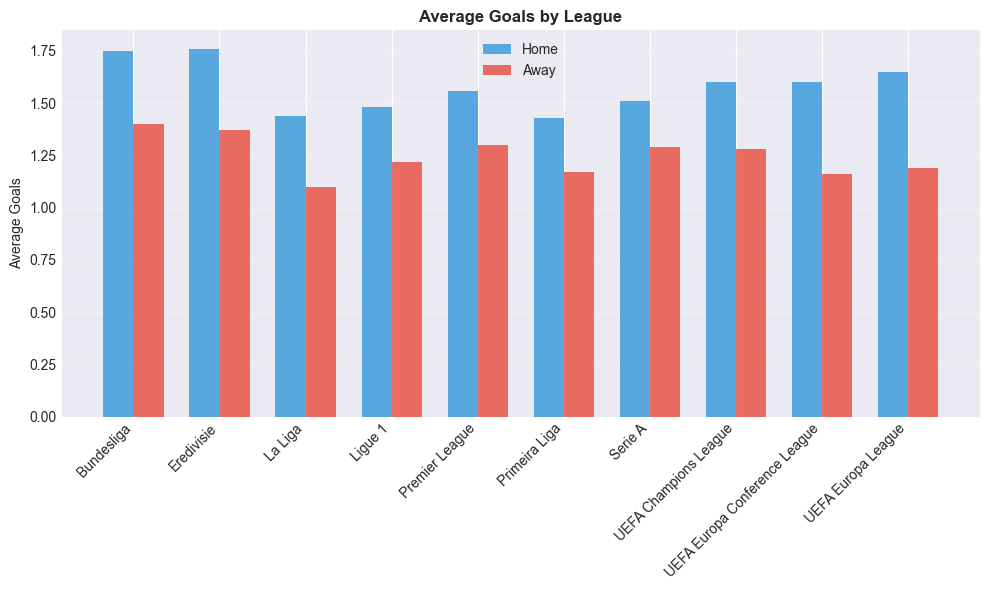

In [368]:
# Average Goals by League
league_goals = df_fixtures.groupby('league_name').agg({
    'home_goals': 'mean',
    'away_goals': 'mean'
}).round(2)

plt.figure(figsize=(10, 6))
x = np.arange(len(league_goals))
width = 0.35

plt.bar(x - width/2, league_goals['home_goals'], width, label='Home', color='#3498db', alpha=0.8)
plt.bar(x + width/2, league_goals['away_goals'], width, label='Away', color='#e74c3c', alpha=0.8)
plt.title('Average Goals by League', fontsize=12, fontweight='bold')
plt.xticks(x, league_goals.index, rotation=45, ha='right')
plt.ylabel('Average Goals')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'average_goals_by_league.png', dpi=300, bbox_inches='tight')
plt.show()


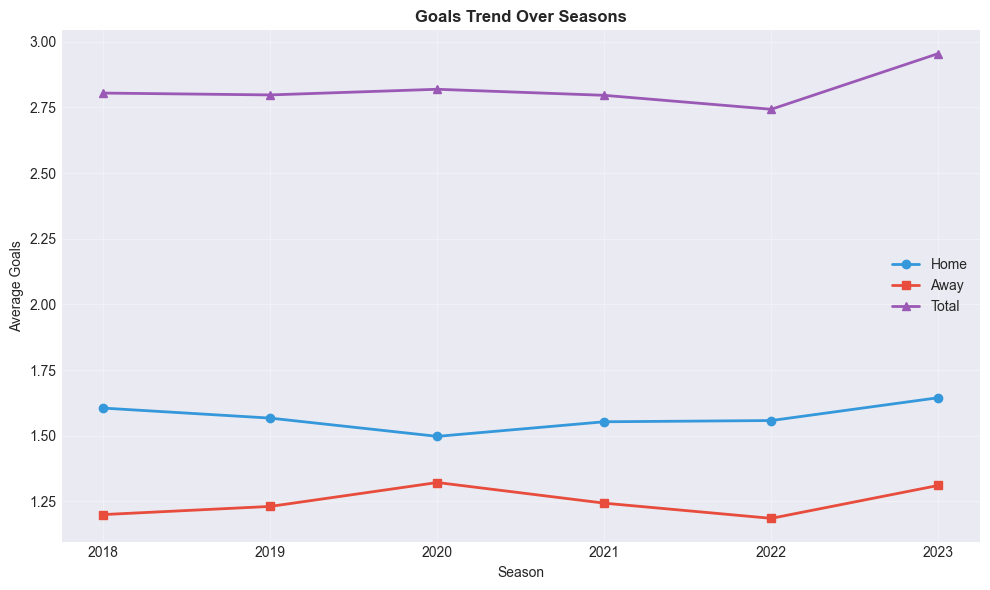

In [369]:
# Goals Trend Over Seasons
season_goals = df_fixtures.groupby('season').agg({
    'home_goals': 'mean',
    'away_goals': 'mean',
    'total_goals': 'mean'
})

plt.figure(figsize=(10, 6))
plt.plot(season_goals.index, season_goals['home_goals'], marker='o', linewidth=2, label='Home', color='#3498db')
plt.plot(season_goals.index, season_goals['away_goals'], marker='s', linewidth=2, label='Away', color='#e74c3c')
plt.plot(season_goals.index, season_goals['total_goals'], marker='^', linewidth=2, label='Total', color='#9b59b6')

plt.title('Goals Trend Over Seasons', fontsize=12, fontweight='bold')
plt.xlabel('Season')
plt.ylabel('Average Goals')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'goals_trend_over_seasons.png', dpi=300, bbox_inches='tight')
plt.show()


### 10. Home Advantage Analysis

In [370]:
# Home Advantage Analysis

print("HOME ADVANTAGE ANALYSIS")

home_wins = (df_fixtures['match_outcome'] == 'H').sum()
draws = (df_fixtures['match_outcome'] == 'D').sum()
away_wins = (df_fixtures['match_outcome'] == 'A').sum()

print(f" Match Results:")
print(f"  Home Wins: {home_wins:,} ({home_wins/len(df_fixtures)*100:.2f}%)")
print(f"  Draws: {draws:,} ({draws/len(df_fixtures)*100:.2f}%)")
print(f"  Away Wins: {away_wins:,} ({away_wins/len(df_fixtures)*100:.2f}%)")

print(f"\n Home Advantage:")
print(f"  Goal Difference: +{df_fixtures['home_goals'].mean() - df_fixtures['away_goals'].mean():.3f}")
print(f"  Win Advantage: {(home_wins - away_wins) / len(df_fixtures) * 100:.2f}% more wins at home")

# Home win % by league
home_win_by_league = df_fixtures.groupby('league_name').apply(
    lambda x: (x['match_outcome'] == 'H').sum() / len(x) * 100
).sort_values(ascending=False)

print(f"\n Home Win % by League:")
print(home_win_by_league.round(2))


HOME ADVANTAGE ANALYSIS
 Match Results:
  Home Wins: 8,413 (44.53%)
  Draws: 4,557 (24.12%)
  Away Wins: 5,924 (31.35%)

 Home Advantage:
  Goal Difference: +0.324
  Win Advantage: 13.17% more wins at home

 Home Win % by League:
league_name
UEFA Europa League              48.410
UEFA Europa Conference League   47.810
Eredivisie                      45.510
UEFA Champions League           45.360
Premier League                  44.690
La Liga                         44.470
Bundesliga                      43.990
Primeira Liga                   43.710
Ligue 1                         41.970
Serie A                         41.560
dtype: float64


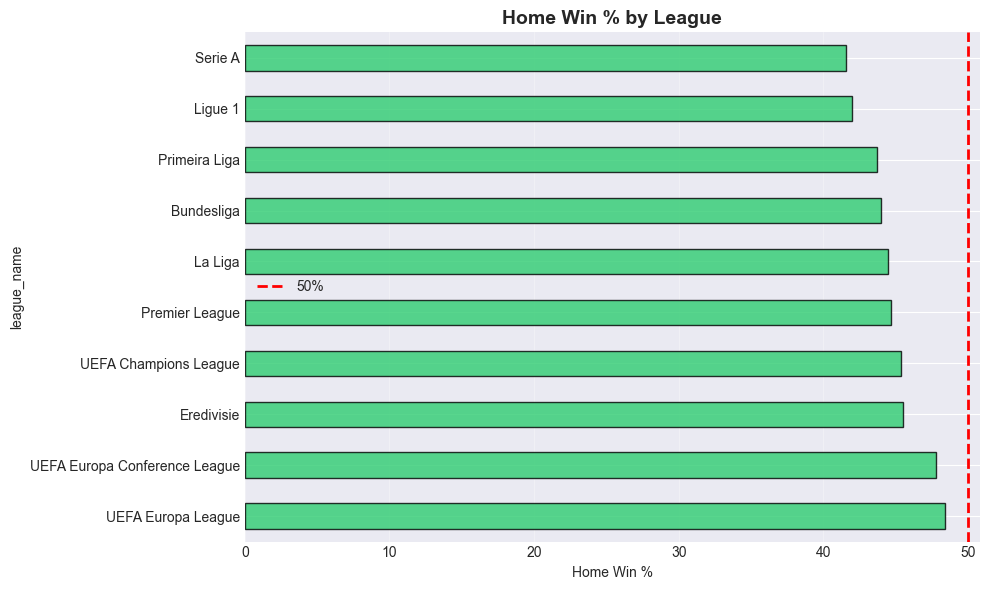

In [371]:
# Home Win % by League
plt.figure(figsize=(10, 6))
home_win_by_league.plot(kind='barh', color='#2ecc71', alpha=0.8, edgecolor='black')
plt.title('Home Win % by League', fontsize=14, fontweight='bold')
plt.xlabel('Home Win %')
plt.axvline(50, color='red', linestyle='--', linewidth=2, label='50%')
plt.legend()
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'home_win_by_league.png', dpi=300, bbox_inches='tight')
plt.show()


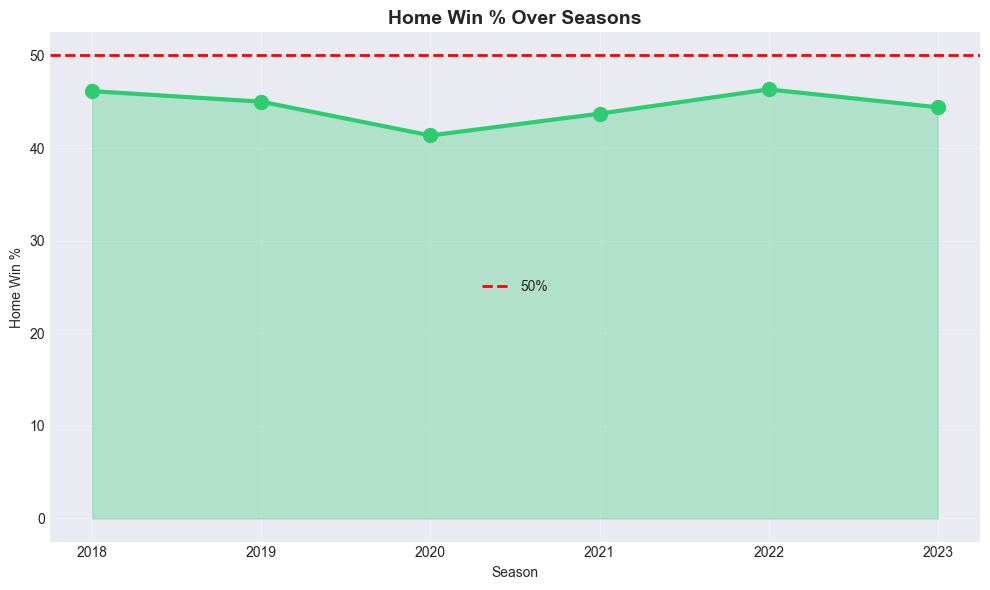

In [372]:
# Home Win % Over Seasons
plt.figure(figsize=(10, 6))
home_win_by_season = df_fixtures.groupby('season').apply(
    lambda x: (x['match_outcome'] == 'H').sum() / len(x) * 100
)

plt.plot(home_win_by_season.index, home_win_by_season.values, marker='o', linewidth=3, markersize=10, color='#2ecc71')
plt.fill_between(home_win_by_season.index, home_win_by_season.values, alpha=0.3, color='#2ecc71')
plt.title('Home Win % Over Seasons', fontsize=14, fontweight='bold')
plt.xlabel('Season')
plt.ylabel('Home Win %')
plt.axhline(50, color='red', linestyle='--', linewidth=2, label='50%')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'home_win_over_seasons.png', dpi=300, bbox_inches='tight')
plt.show()


### 11. League Comparison

In [373]:

print("LEAGUE COMPARISON")

league_comparison = df_fixtures.groupby('league_name').agg({
    'fixture_id': 'count',
    'home_goals': 'mean',
    'away_goals': 'mean',
    'total_goals': 'mean'
}).round(3)

league_comparison.columns = ['Total_Matches', 'Avg_Home_Goals', 'Avg_Away_Goals', 'Avg_Total_Goals']

# Add outcome percentages
for league in df_fixtures['league_name'].unique():
    league_data = df_fixtures[df_fixtures['league_name'] == league]
    league_comparison.loc[league, 'Home_Win_%'] = (league_data['match_outcome'] == 'H').sum() / len(league_data) * 100
    league_comparison.loc[league, 'Draw_%'] = (league_data['match_outcome'] == 'D').sum() / len(league_data) * 100
    league_comparison.loc[league, 'Away_Win_%'] = (league_data['match_outcome'] == 'A').sum() / len(league_data) * 100

league_comparison = league_comparison.sort_values('Avg_Total_Goals', ascending=False)

print(" League Comparison Table:")
display(league_comparison)
# If you have a FEATURES_PATH defined as a pathlib.Path
league_comparison.to_csv(TABLES_PATH / 'league_comparison.csv', index=False)
print(f"Saved cleaned dataset to '{TABLES_PATH}/league_comparison.csv'")



LEAGUE COMPARISON
 League Comparison Table:


,Total_Matches,Avg_Home_Goals,Avg_Away_Goals,Avg_Total_Goals,Home_Win_%,Draw_%,Away_Win_%
league_name,,,,,,,
Bundesliga,1848,1.752,1.399,3.152,43.994,24.621,31.385
Eredivisie,1828,1.760,1.367,3.127,45.514,22.593,31.893
UEFA Champions League,1250,1.601,1.279,2.880,45.360,22.080,32.560
Premier League,2280,1.564,1.300,2.864,44.693,22.061,33.246
UEFA Europa League,1917,1.653,1.188,2.840,48.409,21.701,29.890
Serie A,2281,1.515,1.289,2.804,41.561,26.260,32.179
UEFA Europa Conference League,1255,1.604,1.162,2.766,47.809,21.992,30.199
Ligue 1,2111,1.480,1.220,2.700,41.971,26.196,31.833
Primeira Liga,1844,1.429,1.171,2.600,43.709,23.590,32.701


Saved cleaned dataset to '/Users/vishalchaudhary/Desktop/Football_Project_FINAL/DOMAIN_APPLICATIONS_PROJECT/results/tables/league_comparison.csv'


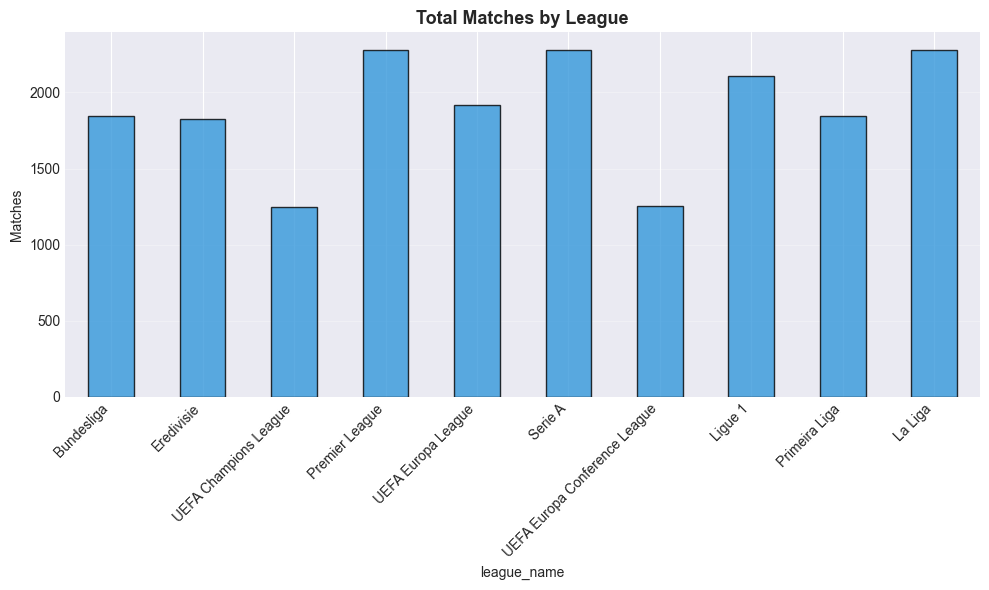

In [374]:
# Total Matches by League
plt.figure(figsize=(10, 6))
league_comparison['Total_Matches'].plot(kind='bar', color='#3498db', alpha=0.8, edgecolor='black')
plt.title('Total Matches by League', fontsize=13, fontweight='bold')
plt.ylabel('Matches')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'total_matches_by_league.png', dpi=300, bbox_inches='tight')
plt.show()


<Figure size 1000x600 with 0 Axes>

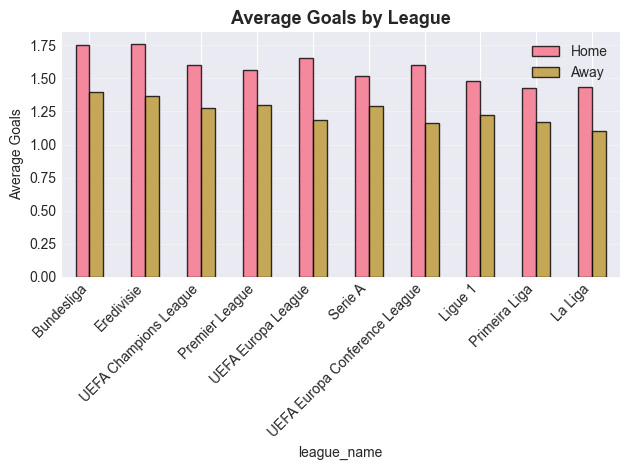

In [375]:
# Average Goals by League
plt.figure(figsize=(10, 6))
league_comparison[['Avg_Home_Goals', 'Avg_Away_Goals']].plot(kind='bar', alpha=0.8, edgecolor='black')
plt.title('Average Goals by League', fontsize=13, fontweight='bold')
plt.ylabel('Average Goals')
plt.xticks(rotation=45, ha='right')
plt.legend(['Home', 'Away'])
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'average_goals_by_league.png', dpi=300, bbox_inches='tight')
plt.show()


<Figure size 1000x600 with 0 Axes>

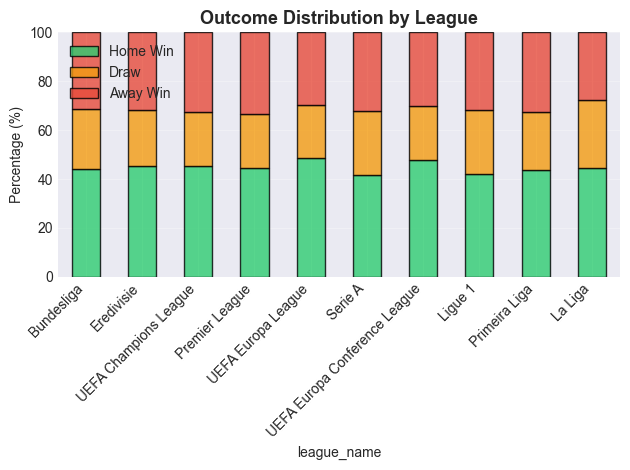

In [376]:
# Outcome Distribution by League
plt.figure(figsize=(10, 6))
outcome_cols = ['Home_Win_%', 'Draw_%', 'Away_Win_%']
league_comparison[outcome_cols].plot(kind='bar', stacked=True,
                                     color=['#2ecc71', '#f39c12', '#e74c3c'],
                                     alpha=0.8, edgecolor='black')
plt.title('Outcome Distribution by League', fontsize=13, fontweight='bold')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(['Home Win', 'Draw', 'Away Win'])
plt.ylim([0, 100])
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'outcome_distribution_by_league.png', dpi=300, bbox_inches='tight')
plt.show()


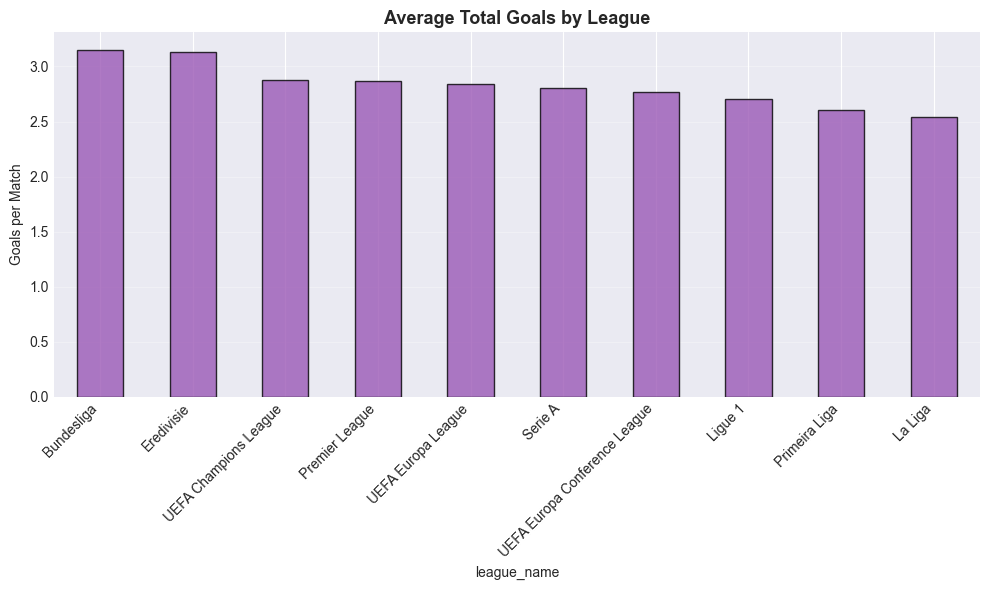

In [377]:
# Average Total Goals by League
plt.figure(figsize=(10, 6))
league_comparison['Avg_Total_Goals'].plot(kind='bar', color='#9b59b6', alpha=0.8, edgecolor='black')
plt.title('Average Total Goals by League', fontsize=13, fontweight='bold')
plt.ylabel('Goals per Match')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'average_total_goals_by_league.png', dpi=300, bbox_inches='tight')
plt.show()


### 12. Scoring Categories

In [378]:
print("SCORING CATEGORIES ANALYSIS")

# Define categories
high_scoring = df_fixtures[df_fixtures['total_goals'] >= 5]
medium_scoring = df_fixtures[(df_fixtures['total_goals'] >= 2) & (df_fixtures['total_goals'] < 5)]
low_scoring = df_fixtures[df_fixtures['total_goals'] < 2]

print(f" Match Categories:")
print(f"  High (5+ goals): {len(high_scoring):,} ({len(high_scoring)/len(df_fixtures)*100:.2f}%)")
print(f"  Medium (2-4 goals): {len(medium_scoring):,} ({len(medium_scoring)/len(df_fixtures)*100:.2f}%)")
print(f"  Low (0-1 goals): {len(low_scoring):,} ({len(low_scoring)/len(df_fixtures)*100:.2f}%)")

# Clean sheet stats
print(f"\n Clean Sheet Statistics:")
print(f"  Home Clean Sheets: {df_fixtures['home_clean_sheet'].sum():,} ({df_fixtures['home_clean_sheet'].mean()*100:.2f}%)")
print(f"  Away Clean Sheets: {df_fixtures['away_clean_sheet'].sum():,} ({df_fixtures['away_clean_sheet'].mean()*100:.2f}%)")
print(f"  Both Teams Scored: {df_fixtures['both_scored'].sum():,} ({df_fixtures['both_scored'].mean()*100:.2f}%)")



SCORING CATEGORIES ANALYSIS
 Match Categories:
  High (5+ goals): 2,984 (15.79%)
  Medium (2-4 goals): 11,595 (61.37%)
  Low (0-1 goals): 4,315 (22.84%)

 Clean Sheet Statistics:
  Home Clean Sheets: 5,841 (30.91%)
  Away Clean Sheets: 4,295 (22.73%)
  Both Teams Scored: 9,984 (52.84%)


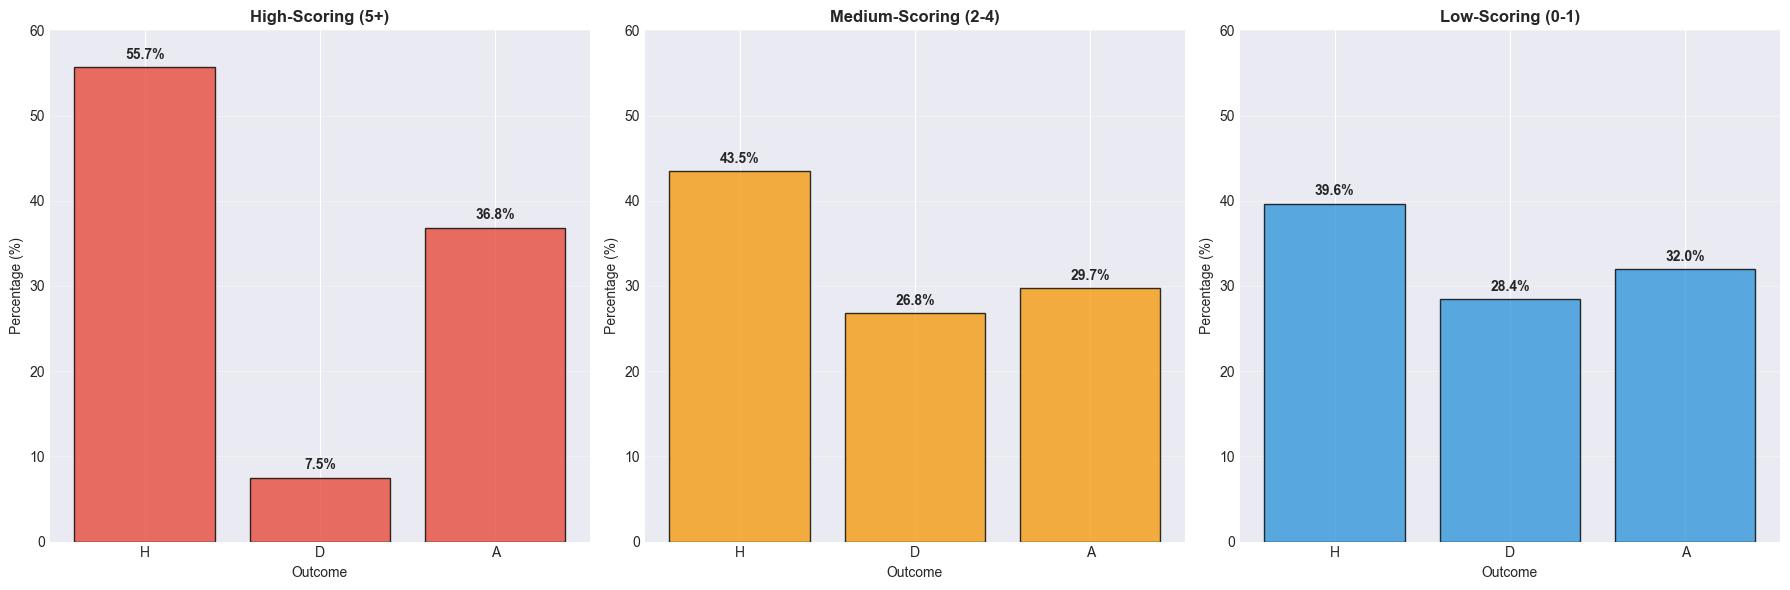

In [379]:
# Visualize
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

categories = [
    (high_scoring, 'High-Scoring (5+)', '#e74c3c'),
    (medium_scoring, 'Medium-Scoring (2-4)', '#f39c12'),
    (low_scoring, 'Low-Scoring (0-1)', '#3498db')
]

for idx, (df_cat, title, color) in enumerate(categories):
    outcome_pct = df_cat['match_outcome'].value_counts(normalize=True) * 100
    outcome_pct = outcome_pct.reindex(['H', 'D', 'A'], fill_value=0)
    
    axes[idx].bar(outcome_pct.index, outcome_pct.values, color=color, alpha=0.8, edgecolor='black')
    axes[idx].set_title(title, fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Outcome')
    axes[idx].set_ylabel('Percentage (%)')
    axes[idx].set_ylim([0, 60])
    axes[idx].grid(axis='y', alpha=0.3)
    
    for i, v in enumerate(outcome_pct.values):
        axes[idx].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'scoring_categories.png', dpi=300, bbox_inches='tight')
plt.show()

### 13: Save Results

In [380]:
print("SAVING PROCESSED DATA")

# Save fixtures with features
df_fixtures.to_csv(PROCESSED_PATH / 'fixtures_with_target.csv', index=False)
print(f" Saved: fixtures_with_target.csv ({len(df_fixtures):,} rows)")

df_2024_test.to_csv(PROCESSED_PATH / 'fixtures_2024_test_with_target.csv', index=False)
print(f" Saved: fixtures_2024_test_with_target.csv ({len(df_2024_test):,} rows)")

# Save cleaned player stats
df_players_clean.to_csv(PROCESSED_PATH / 'players_top500_cleaned.csv', index=False)
print(f" Saved: players_top500_cleaned.csv ({len(df_players_clean):,} rows)")

# Save team strength
team_strength.to_csv(PROCESSED_PATH / 'team_strength_by_players.csv', index=False)
print(f" Saved: team_strength_by_players.csv ({len(team_strength):,} rows)")

# Save injury impact
injury_impact.to_csv(PROCESSED_PATH / 'injury_impact_by_team.csv', index=False)
print(f" Saved: injury_impact_by_team.csv ({len(injury_impact):,} rows)")

# Save insights
insights = {
    'analysis_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'fixtures': {
        'total_matches': int(len(df_fixtures)),
        'home_win_pct': float((df_fixtures['match_outcome']=='H').mean() * 100),
        'draw_pct': float((df_fixtures['match_outcome']=='D').mean() * 100),
        'away_win_pct': float((df_fixtures['match_outcome']=='A').mean() * 100),
        'avg_home_goals': float(df_fixtures['home_goals'].mean()),
        'avg_away_goals': float(df_fixtures['away_goals'].mean()),
        'avg_total_goals': float(df_fixtures['total_goals'].mean()),
        'btts_pct': float(df_fixtures['both_scored'].mean() * 100),
    },
    'players': {
        'total_records': int(len(df_players_clean)),
        'unique_players': int(df_players_clean['player_id'].nunique()),
        'avg_rating': float(df_players_clean['rating'].mean()),
        'avg_goals': float(df_players_clean['goals_total'].mean()),
        'avg_assists': float(df_players_clean['assists'].mean()),
    },
    'injuries': {
        'total_injuries': int(len(df_injuries)),
        'unique_players_injured': int(df_injuries['player_id'].nunique()),
        'avg_injuries_per_season': float(df_injuries.groupby('season').size().mean()),
    },
    'leagues': df_fixtures['league_name'].unique().tolist(),
    'seasons': sorted(df_fixtures['season'].unique().tolist())
}

with open(RESULTS_PATH / 'eda_insights.json', 'w') as f:
    json.dump(insights, f, indent=4)
print(f" Saved: eda_insights.json")

league_comparison.to_csv(RESULTS_PATH / 'league_comparison.csv')
print(f" Saved: league_comparison.csv")


SAVING PROCESSED DATA
 Saved: fixtures_with_target.csv (18,894 rows)
 Saved: fixtures_2024_test_with_target.csv (3,342 rows)
 Saved: players_top500_cleaned.csv (10,266 rows)
 Saved: team_strength_by_players.csv (862 rows)
 Saved: injury_impact_by_team.csv (546 rows)
 Saved: eda_insights.json
 Saved: league_comparison.csv


### 14. Final Summary 

In [381]:
print("FINAL SUMMARY")

summary_table = pd.DataFrame({
    'Metric': [
        'Total Matches (2018-2023)',
        '2024 Test Matches',
        'Home Wins',
        'Draws',
        'Away Wins',
        'Home Win %',
        'Draw %',
        'Away Win %',
        'Avg Home Goals',
        'Avg Away Goals',
        'Avg Total Goals',
        'BTTS %',
        'Home Clean Sheet %',
        '---',
        'Player Records (Cleaned)',
        'Unique Players',
        'Avg Player Rating',
        '---',
        'Total Injuries',
        'Unique Injured Players',
        '---',
        'Unique Leagues',
        'Seasons Covered'
    ],
    'Value': [
        f"{len(df_fixtures):,}",
        f"{len(df_2024_test):,}",
        f"{(df_fixtures['match_outcome']=='H').sum():,}",
        f"{(df_fixtures['match_outcome']=='D').sum():,}",
        f"{(df_fixtures['match_outcome']=='A').sum():,}",
        f"{(df_fixtures['match_outcome']=='H').mean()*100:.2f}%",
        f"{(df_fixtures['match_outcome']=='D').mean()*100:.2f}%",
        f"{(df_fixtures['match_outcome']=='A').mean()*100:.2f}%",
        f"{df_fixtures['home_goals'].mean():.3f}",
        f"{df_fixtures['away_goals'].mean():.3f}",
        f"{df_fixtures['total_goals'].mean():.3f}",
        f"{df_fixtures['both_scored'].mean()*100:.2f}%",
        f"{df_fixtures['home_clean_sheet'].mean()*100:.2f}%",
        "---",
        f"{len(df_players_clean):,}",
        f"{df_players_clean['player_id'].nunique():,}",
        f"{df_players_clean['rating'].mean():.2f}",
        "---",
        f"{len(df_injuries):,}",
        f"{df_injuries['player_id'].nunique():,}",
        "---",
        f"{df_fixtures['league_name'].nunique()}",
        f"{df_fixtures['season'].nunique()} (2018-2023)"
    ]
})

display(summary_table)



FINAL SUMMARY


,Metric,Value
0,Total Matches (2018-2023),"18,894"
1,2024 Test Matches,"3,342"
2,Home Wins,"8,413"
3,Draws,"4,557"
4,Away Wins,"5,924"
5,Home Win %,44.53%
6,Draw %,24.12%
7,Away Win %,31.35%
8,Avg Home Goals,1.572
9,Avg Away Goals,1.248


In [382]:
print(" EXPLORATORY DATA ANALYSIS COMPLETE!")

print(f"""
COMPLETED TASKS:
    Loaded 8 datasets successfully (including injuries & player stats)
    Assessed data quality across all datasets
    Created target variable (H/D/A)
    Analyzed {len(df_fixtures):,} historical matches
    Analyzed {len(df_players_clean):,} player performance records
    Analyzed {len(df_injuries):,} injury records
    Generated comprehensive visualizations
    Identified key patterns and insights
    Saved processed data

KEY INSIGHTS:
    Match Outcomes:
      • Home Win Rate: {(df_fixtures['match_outcome']=='H').mean()*100:.1f}%
      • Draw Rate: {(df_fixtures['match_outcome']=='D').mean()*100:.1f}% (Class Imbalance!)
      • Away Win Rate: {(df_fixtures['match_outcome']=='A').mean()*100:.1f}%
   
    Goals:
      • Avg Goals/Match: {df_fixtures['total_goals'].mean():.2f}
      • Home Advantage: +{df_fixtures['home_goals'].mean() - df_fixtures['away_goals'].mean():.3f} goals
   
    Player Performance:
      • Avg Player Rating: {df_players_clean['rating'].mean():.2f}
      • Top players identified per league/season
      • Team strength metrics calculated
   
    Injuries:
      • Total injuries tracked: {len(df_injuries):,}
      • Injury impact quantified per team-season
      • Can be used for "available squad strength" features

IMPORTANT FINDINGS:
    Clear HOME ADVANTAGE exists
    Class imbalance: Draws underrepresented
    Predictable goal patterns
    Player quality varies significantly by league
    Injuries can significantly impact team performance
    Stable trends over time

NEXT STEPS FOR FEATURE ENGINEERING:
   1. Merge player stats with team data
   2. Calculate "available squad strength" using injuries
   3. Create rolling form metrics using player ratings
   4. Aggregate player stats at team level (avg rating, goals, assists)
   5. Injury-adjusted team strength features
   6. Key player availability indicators

SAVED FILES:
    Processed Data:
      • {PROCESSED_PATH / 'fixtures_with_target.csv'}
      • {PROCESSED_PATH / 'fixtures_2024_test_with_target.csv'}
      • {PROCESSED_PATH / 'players_top500_cleaned.csv'}
      • {PROCESSED_PATH / 'team_strength_by_players.csv'}
      • {PROCESSED_PATH / 'injury_impact_by_team.csv'}
   
    Results:
      • {RESULTS_PATH / 'eda_insights.json'}
      • {RESULTS_PATH / 'league_comparison.csv'}
   
    Figures:
      • player_stats_analysis.png
      • injuries_analysis.png
      • target_variable_analysis.png
      • goals_analysis.png
      • home_advantage_analysis.png
      • league_comparison.png
      • scoring_categories.png

Completed at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
""")

 EXPLORATORY DATA ANALYSIS COMPLETE!

COMPLETED TASKS:
    Loaded 8 datasets successfully (including injuries & player stats)
    Assessed data quality across all datasets
    Created target variable (H/D/A)
    Analyzed 18,894 historical matches
    Analyzed 10,266 player performance records
    Analyzed 37,198 injury records
    Generated comprehensive visualizations
    Identified key patterns and insights
    Saved processed data

KEY INSIGHTS:
    Match Outcomes:
      • Home Win Rate: 44.5%
      • Draw Rate: 24.1% (Class Imbalance!)
      • Away Win Rate: 31.4%

    Goals:
      • Avg Goals/Match: 2.82
      • Home Advantage: +0.324 goals

    Player Performance:
      • Avg Player Rating: 6.74
      • Top players identified per league/season
      • Team strength metrics calculated

    Injuries:
      • Total injuries tracked: 37,198
      • Injury impact quantified per team-season
      • Can be used for "available squad strength" features

IMPORTANT FINDINGS:
    Clear HOME 